
# 🏥 Heart Attack Risk Prediction - Exploratory Data Analysis (EDA)  
### 📊 Data Analysis Module Validation  

## 👨‍💻 Realized by:  
# **HEDI KSENTINI**  

## 🎓 Supervised by:  
# **AMOR MASSEOUD**  
## 📝 Introduction  
Cardiovascular diseases remain one of the leading causes of mortality worldwide. Early identification of individuals at high risk of heart attacks can significantly enhance prevention strategies and improve healthcare outcomes.  

In this project, we conduct an **Exploratory Data Analysis (EDA)** on a dataset related to heart attack risk prediction. Our goal is to extract meaningful insights, identify patterns, and understand the key risk factors associated with heart attacks.

## 📌 Objectives  
- Understand the dataset and its structure  
- Identify missing values, outliers, and inconsistencies  
- Perform univariate and multivariate analyses to detect trends  
- Visualize key correlations between risk factors and heart attack risk  
- Provide insights that can aid in predictive modeling

## 📂 Dataset Overview  
The dataset includes various medical and lifestyle-related attributes for patients. Below is a summary of the features:

- **Demographics**: Age, Sex, Country, Continent, Hemisphere, Income  
- **Medical History**: Cholesterol, Blood Pressure, Heart Rate, Diabetes, Family History, Previous Heart Problems, Medication Use  
- **Lifestyle Factors**: Smoking, Obesity, Alcohol Consumption, Diet, Physical Activity, Exercise Hours, Sedentary Hours, Stress Level, Sleep Hours  
- **Biometrics**: BMI, Triglycerides  
- **Target Variable**: Heart Attack Risk (prediction target)

## 📌 Notebook Structure  
1. **Data Loading & Cleaning** – Handling missing values, checking for duplicates, and ensuring data consistency  
2. **Descriptive Statistics** – Exploring distributions of numerical and categorical features  
3. **Data Visualization** – Using histograms, box plots, heatmaps, and bar charts to uncover insights  
4. **Feature Relationships** – Analyzing how various features relate to heart attack risk  
5. **Conclusion & Next Steps** – Summarizing key findings and proposing directions for future analysis  

Let’s dive into the analysis! 🚀


# **Table of Contents** <a id='toc0_'></a>  

- [🏥 Heart Attack Risk Prediction](#toc1_)  
  - [1️⃣ Introduction](#toc1_1_)  
  - [2️⃣ Importing Libraries](#toc1_2_)  
  - [3️⃣ Data Exploration](#toc1_3_)  
    - [3.1 Initial Overview of the Data](#toc1_3_1_)  
    - [3.2 Data Preprocessing](#toc1_3_2_)  
    - [3.3 Statistical Summary](#toc1_3_3_)  
    - [3.4 Hypothesis Testing](#toc1_3_4_)  
      - [3.4.1 Chi-Square Test for Categorical Features](#toc1_3_4_1_)  
      - [3.4.2 T-Test/ANOVA for Numerical Features](#toc1_3_4_2_)  
      - [3.4.3 Correlation Analysis](#toc1_3_4_3_)  
  - [4️⃣ Dimensionality Reduction](#toc1_4_)  
    - [4.1 Hierarchical Clustering](#toc1_4_1_)  
    - [4.2 Principal Component Analysis (PCA)](#toc1_4_2_)  
  - [5️⃣ Evaluating Preprocessed Datasets for Classification](#toc1_5_)  
    - [5.1 Overview of the Approach](#toc1_5_1_)  
    - [5.2 Implementing Grid Search for Model Optimization](#toc1_5_2_)  
    - [5.3 Comparison of Different Preprocessing Strategies](#toc1_5_3_)  
  - [6️⃣ Classification Models](#toc1_6_)  
    - [6.1 Utility Functions for Model Evaluation](#toc1_6_1_)  
    - [6.2 Logistic Regression](#toc1_6_2_)  
    - [6.3 K-Nearest Neighbors (KNN)](#toc1_6_3_)  
    - [6.4 Support Vector Machine (SVM)](#toc1_6_4_)  
    - [6.5 Decision Tree Classifier](#toc1_6_5_)  
    - [6.6 Random Forest Classifier](#toc1_6_6_)  
  - [7️⃣ Model Performance Comparison](#toc1_7_)  
  - [8️⃣ Conclusion & Insights](#toc1_8_)  

<!-- vscode-jupyter-toc-config  
	numbering=false  
	anchor=true  
	flat=false  
	minLevel=1  
	maxLevel=6  
	/vscode-jupyter-toc-config -->  
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->ITE YOUR TEXT IN THIS CELL -->  


![Heart Disease](kk.jpg)


## <a id='toc1_1_'></a>[1️⃣Introduction ](#toc0_)


In today's healthcare landscape, **# PREDICTING and PREVENTING HEART ATTACKS** is of **critical importance** for improving patient outcomes and reducing the burden on medical systems. **CARDIOVASCULAR DISEASES** remain one of the leading causes of mortality worldwide, and early identification of **HIGH-RISK INDIVIDUALS** can significantly enhance **PREVENTIVE CARE and MEDICAL INTERVENTIONS**. By leveraging **DATA-DRIVEN INSIGHTS**, healthcare providers can proactively address key risk factors and implement targeted strategies to reduce **HEART ATTACK OCCURRENCES**.   

Our primary goal is to perform an in-depth **EXPLORATORY DATA ANALYSIS (EDA)** to uncover **PATTERNS and CORRELATIONS** that contribute to **HEART ATTACK RISK**. By utilizing **SUPERVISED CLASSIFICATION TECHNIQUES**, we aim to develop **PREDICTIVE MODELS** capable of identifying individuals most susceptible to **HEART ATTACKS**, ultimately aiding in **EARLY DIAGNOSIS and PREVENTIVE CARE STRATEGIES**.  



## <a id='toc1_2_'></a>[2️⃣ Importing the libraries](#toc0_)


In [60]:
# Data Handling & Processing
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats
import statsmodels.api as sm

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Machine Learning Models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score




# do not show any warnings
import warnings
warnings.filterwarnings('ignore')

## <a id='toc1_3_'></a>[3️⃣ Data Exploration](#toc0_)


### <a id='toc1_3_1_'></a>[3.1 Initial Overview of the Data](#toc0_)


In [61]:
# Load the datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
y = train['Heart Attack Risk']  # Target variable
X = train.drop(columns=['Heart Attack Risk'])  # Features
# Combine datasets (assuming you want to keep train and test together for preprocessing)
df = pd.concat([X, test])



# Dataset size
print("The dataset has %d rows and %d columns." % train.shape)

# Dataset features' types
train.dtypes

The dataset has 7010 rows and 26 columns.


,0
Patient ID,object
Age,int64
Sex,object
Cholesterol,int64
Blood Pressure,object
Heart Rate,int64
Diabetes,int64
Family History,int64
Smoking,int64
Obesity,int64


In [62]:
train["Heart Attack Risk"]

,Heart Attack Risk
0,1
1,1
2,0
3,1
4,1
...,...
7005,0
7006,0
7007,0
7008,1


In [63]:
train.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

## 📊 **Dataset Overview:**

The dataset provided for **Heart Attack Risk Prediction** contains various medical and lifestyle-related features for individuals. Below is an overview of the columns included in the dataset:

| Column | Description |
|--------|-------------|
| **Patient ID** | Unique identifier for each patient. |
| **Age** | Age of the patient in years. |
| **Sex** | Gender of the patient (Male/Female). |
| **Cholesterol** | Cholesterol level of the patient . |
| **Blood Pressure** | Blood pressure of the patient, typically presented as systolic/diastolic (e.g., 120/80). |
| **Heart Rate** | Average heart rate of the patient in beats per minute (bpm). |
| **Diabetes** | Whether the patient has diabetes (Yes/No). |
| **Family History** | Whether the patient has a family history of heart disease (Yes/No). |
| **Smoking** | Whether the patient smokes (Yes/No). |
| **Obesity** | Whether the patient is obese (Yes/No). |
| **Alcohol Consumption** | Whether the patient consumes alcohol (Yes/No). |
| **Exercise Hours Per Week** | The number of hours per week the patient engages in physical exercise. |
| **Diet** | The type of diet the patient follows (e.g., Healthy, Unhealthy,Average). |
| **Previous Heart Problems** | Whether the patient has had previous heart problems (Yes/No). |
| **Medication Use** | Whether the patient is on medication (Yes/No). |
| **Stress Level** | The stress level of the patient, usually on a scale of 1-10 (1 being very low, 10 being very high). |
| **Sedentary Hours Per Day** | The number of hours the patient spends in sedentary activities per day. |
| **Income** | Income level of the patient (e.g., Low, Medium, High). |
| **BMI** | Body Mass Index of the patient, a measure of body fat based on height and weight. |
| **Triglycerides** | Triglyceride levels in the blood, an important lipid measure for cardiovascular health. |
| **Physical Activity Days Per Week** | The number of days per week the patient engages in physical activity. |
| **Sleep Hours Per Day** | Average number of hours the patient sleeps per day. |
| **Country** | The country of residence of the patient. |
| **Continent** | The continent where the patient resides. |
| **Hemisphere** | The hemisphere where the patient resides (Northern/Southern). |
| **Heart Attack Risk** | The target variable indicating whether the patient is at risk of a heart attack (Yes/No). |


In [64]:
if train.isnull().values.any():
    print("There are some missing values in the dataset.")
else:
    print("No missing values in the dataset")

No missing values in the dataset


In [65]:
train.nunique()

,0
Patient ID,7010
Age,73
Sex,2
Cholesterol,281
Blood Pressure,3590
Heart Rate,71
Diabetes,2
Family History,2
Smoking,2
Obesity,2


### <a id='toc1_3_2_'></a>[3.2 Data Preprocessing](#toc0_)


### Dataset Features Overview

Our dataset contains **25 columns** with the following key attributes:

- **Patient Identification**: `Patient ID`  
- **Demographics**: `Age`, `Sex`, `Country`, `Continent`, `Hemisphere`  
- **Vital Signs**:  
  - `Blood Pressure`  
  - `Heart Rate`  
  - `Cholesterol`  
  - `BMI`  
  - `Triglycerides`  
- **Lifestyle Factors**:  
  - `Smoking`  
  - `Alcohol Consumption`  
  - `Exercise Hours Per Week`  
  - `Sedentary Hours Per Day`  
  - `Physical Activity Days Per Week`  
  - `Sleep Hours Per Day`  
  - `Stress Level`  
  - `Diet`  
- **Medical History**:  
  - `Diabetes`  
  - `Family History`  
  - `Previous Heart Problems`  
  - `Medication Use`  
- **Socioeconomic**: `Income`  

This comprehensive set of features enables us to analyze both clinical and lifestyle risk factors for heart disease.

In [66]:
df.columns = [s.replace(" ", "_") for s in df.columns]

In [67]:
# 1. Split Blood Pressure into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=["Blood_Pressure"], inplace=True)

In [68]:
df["Diastolic_BP"]

,Diastolic_BP
0,90
1,105
2,109
3,62
4,110
...,...
1748,64
1749,92
1750,89
1751,94


In [69]:
# 4. Calculate Stress-Sleep Ratio (with handling for zero sleep hours)
df['Stress_Sleep_Ratio'] = np.where(df['Sleep_Hours_Per_Day'] > 0,
                                   df['Stress_Level'] / df['Sleep_Hours_Per_Day'],
                                   np.nan)

In [70]:
# 5. Encode Diet categories numerically (ordinal encoding)
diet_mapping = {'Unhealthy': 0, 'Average': 1, 'Healthy': 2}
df['Diet_Score'] = df['Diet'].map(diet_mapping)
df.drop(columns=["Diet"], inplace=True)

In [71]:
# 6. Encode sex column
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

In [72]:
# Verify the new features
print(df[['Systolic_BP', 'Diastolic_BP',
          'Stress_Sleep_Ratio', 'Diet_Score']].head())

   Systolic_BP  Diastolic_BP  Stress_Sleep_Ratio  Diet_Score
0          129            90            0.285714           0
1          159           105            1.000000           1
2          161           109            0.300000           1
3          120            62            0.777778           2
4          153           110            0.200000           2


In [73]:
# Create a column to check if a person has any medical condition (at least one feature = 1)
medical_features = ['Diabetes', 'Family_History', 'Previous_Heart_Problems', 'Medication_Use']

df['Has_Medical_Condition'] = (df[medical_features].sum(axis=1) > 0).astype(int)


In [74]:
df['Physical_Mental_Health_Score'] = (
    1.3 * df['Stress_Level'] +
    1.1 * df['Sedentary_Hours_Per_Day'] -
    1.7 * df['Exercise_Hours_Per_Week'] +
    1.2 * df['Sleep_Hours_Per_Day'] -  # Sleep quality/quantity
    1.5 * df['Diet_Score'] +  # Diet quality
    (-0.05) * df['Age'] +  # Age factor
    (-1.8) * df['Has_Medical_Condition']  # Medical condition
)

In [75]:
df['Lifestyle_Risk_Score'] = (
    2 * df['Smoking'] +  # Smoking weight
    1 * (df['BMI'] > 30) +  # Obesity weight (BMI > 30)
    1 * df['Alcohol_Consumption'] +  # Alcohol consumption weight
    (-1) * df['Exercise_Hours_Per_Week'] +  # Exercise weight
    (-2) * df['Diet_Score']  # Diet quality weight
)

In [76]:
df['Health_Risk_Score'] = (
    0.25 * (df['Cholesterol'] - 150).clip(lower=0)/50 +       # Total cholesterol (mg/dL)
    0.15 * (df['Heart_Rate'] - 60).clip(lower=0)/10 +         # Resting heart rate (bpm)
    0.20 * (df['BMI'] - 20).clip(lower=0)/5 +                 # Body Mass Index (kg/m²)
    0.30 * (df['Triglycerides'] - 100).clip(lower=0)/50 +     # Triglycerides (mg/dL)
    0.40 * (df['Systolic_BP'] - 120).clip(lower=0)/10 +       # Systolic BP (mmHg)
    0.30 * (df['Diastolic_BP'] - 80).clip(lower=0)/5 +        # Diastolic BP (mmHg)
    0.25 * (df['Age'] - 30).clip(lower=0)/10 +                # Age (years)
    0.35 * df['Smoking']                                       # Smoking status (1=yes, 0=no)
)

In [77]:
# Define custom bin edges and labels for the training set only
min_value = df['Physical_Mental_Health_Score'].min()
max_value = df['Physical_Mental_Health_Score'].max()

bins = [min_value , 0, max_value ]  # Slightly expanding the range to include all valueslabels = ['Low', 'High']
labels = ['Low', 'High']

# Categorize the Physical_Mental_Health_Score column in the training set
df['Physical_Mental_Health_Score_Category'] = pd.cut(
    df['Physical_Mental_Health_Score'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    duplicates='drop'  # Handle non-unique bin edges
)


In [78]:
min_val = df['Lifestyle_Risk_Score'].min()
max_val = df['Lifestyle_Risk_Score'].max()

# Adjust bins to ensure coverage of all values
bins = [min_val - 0.01, -10, max_val + 0.01]  # Ensure coverage of entire range
labels = ['Low', 'High']

# Apply pd.cut with proper bins
df['Lifestyle_Risk_Category'] = pd.cut(df['Lifestyle_Risk_Score'], bins=bins, labels=labels, right=True)

In [79]:
# Create Age Groups first (we'll use this for multiple plots)
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 30, 45, 60, 75, 100],
                          labels=['<30', '30-45', '45-60', '60-75', '75+'])

In [80]:
# Check the min and max values of your Health_Risk_Score column
min_val = df['Health_Risk_Score'].min()
max_val = df['Health_Risk_Score'].max()

bins = [min_val - 0.01, 3.0, 6.3, max_val + 0.01]  # Slightly expand bins to include all data points
labels = ['Low', 'Medium', 'High']

# Apply pd.cut with proper bins
df['Risk_Category'] = pd.cut(df['Health_Risk_Score'], bins=bins, labels=labels, right=True)


In [81]:
df["Activity_Sedentary_Balance"] = df["Physical_Activity_Days_Per_Week"] / ( df["Sedentary_Hours_Per_Day"] * 7)


In [82]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Sex,0
Cholesterol,0
Heart_Rate,0
Diabetes,0
Family_History,0
Smoking,0
Obesity,0
Alcohol_Consumption,0


### <a id='toc1_3_3_'></a>[3.3 Statistical Summary](#toc0_)

The following <u>statistical measures</u> can be seen for each column using the describe-function of DataFrame of the pandas library:

- **count:** number of samples
- **mean:** the mean of this attribute among all samples
- **std:** the standard deviation of this attribute
- **min:** the minimal value of this attribute
- **25%:** the lower percentile
- **50%:** the median
- **75%:** the upper percentile
- **max:** the maximal value of this attribute


In [83]:
df.describe()

,Age,Sex,Cholesterol,Heart_Rate,Diabetes,Family_History,Smoking,Obesity,Alcohol_Consumption,Exercise_Hours_Per_Week,...,Sleep_Hours_Per_Day,Systolic_BP,Diastolic_BP,Stress_Sleep_Ratio,Diet_Score,Has_Medical_Condition,Physical_Mental_Health_Score,Lifestyle_Risk_Score,Health_Risk_Score,Activity_Sedentary_Balance
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,...,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,0.697364,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,...,7.023508,135.075659,85.156111,0.853845,1.007874,0.953669,-0.806214,-9.195386,5.407300,0.432375
std,21.249509,0.459425,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,...,1.988473,26.349976,14.676565,0.540435,0.817134,0.210213,11.540206,6.090389,1.828225,8.433991
min,18.000000,0.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,...,4.000000,90.000000,60.000000,0.100000,0.000000,0.000000,-32.642224,-23.807181,0.225274,0.000000
25%,35.000000,0.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,...,5.000000,112.000000,72.000000,0.428571,0.000000,1.000000,-9.744607,-14.201141,4.080867,0.036172
50%,54.000000,1.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,...,7.000000,135.000000,85.000000,0.777778,1.000000,1.000000,-0.834985,-9.278926,5.388060,0.082655
75%,72.000000,1.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,...,9.000000,158.000000,98.000000,1.166667,2.000000,1.000000,7.933358,-4.103096,6.689912,0.165432
max,90.000000,1.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,...,10.000000,180.000000,110.000000,2.500000,2.000000,1.000000,31.331290,3.994891,11.762032,565.454755


## 📊 Data Visualization

Now that we've cleaned and preprocessed our data, we'll visualize key patterns and relationships. Our goals are:

1. **Understand Distributions**:
   - Numerical features: `Age`, `Cholesterol`, `Blood Pressure`
   - Categorical features: `Sex`, `Smoking Status`, `BMI_Category`

2. **Identify Risk Correlations**:
   - How clinical measures (BP, Cholesterol) relate to heart attack risk
   - Lifestyle factors (Exercise, Diet) vs risk outcomes

3. **Spot Geographic Trends**:
   - Risk distribution across `Hemisphere` and `Continent`
   - Country-level patterns (if data permits)

4. **Explore Interactions**:
   - Stress-Sleep imbalance vs risk
   - Exercise/Sedentary beh['figure.figsize'] = (10, 6)

In [84]:
# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(160, 100))
plt.style.use('ggplot')


<Figure size 16000x10000 with 0 Axes>

## Demographic visualization

In [85]:
train =df.iloc[:len(X)]  # Retrieve the first len(X) rows

train['Heart Attack Risk'] = y  # Attach target from train set

In [86]:
print(train["Heart Attack Risk"])

0       1
1       1
2       0
3       1
4       1
       ..
7005    0
7006    0
7007    0
7008    1
7009    0
Name: Heart Attack Risk, Length: 7010, dtype: int64


Text(0.5, 1.0, 'Age Distribution by Risk Group')

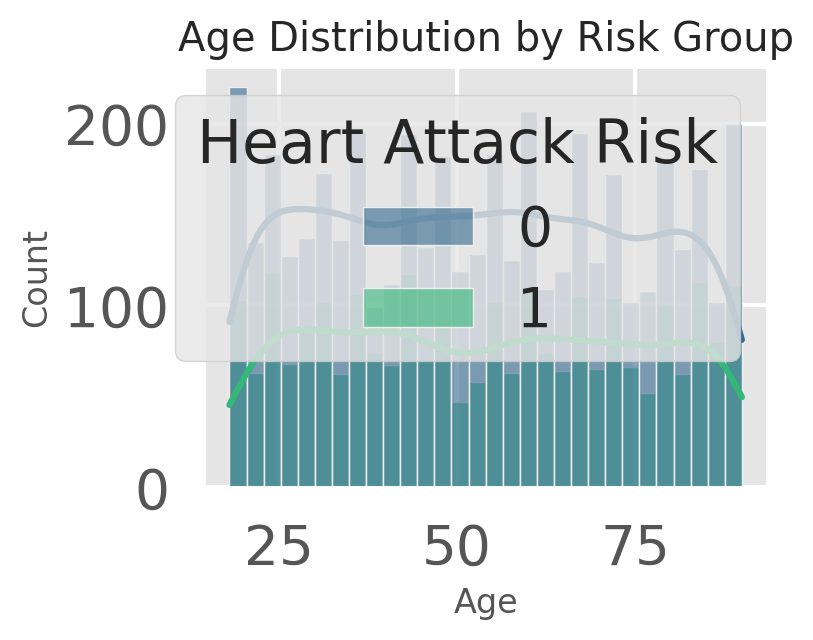

In [87]:
# 1. Age vs Risk
# ------------------
plt.figure(figsize=(8, 6), dpi=200)  # Higher resolution

plt.subplot(2, 2, 1)
sns.histplot(data=train, x='Age', hue='Heart Attack Risk',
             bins=30, kde=True, palette='viridis', alpha=0.6)
plt.title("Age Distribution by Risk Group")

### Key Observations

1. **Heart attacks are less common in younger individuals (left side of the graph).**  

2. **Heart attack risk increases with age, especially from 40 to 80 years old.**  

3. **Even at older ages, some individuals are in the low-risk group, meaning age alone does not determine heart risk—other factors like cholesterol, blood pressure, and lifestyle play a role.**


Text(0.5, 1.0, 'Average Risk by Gender')

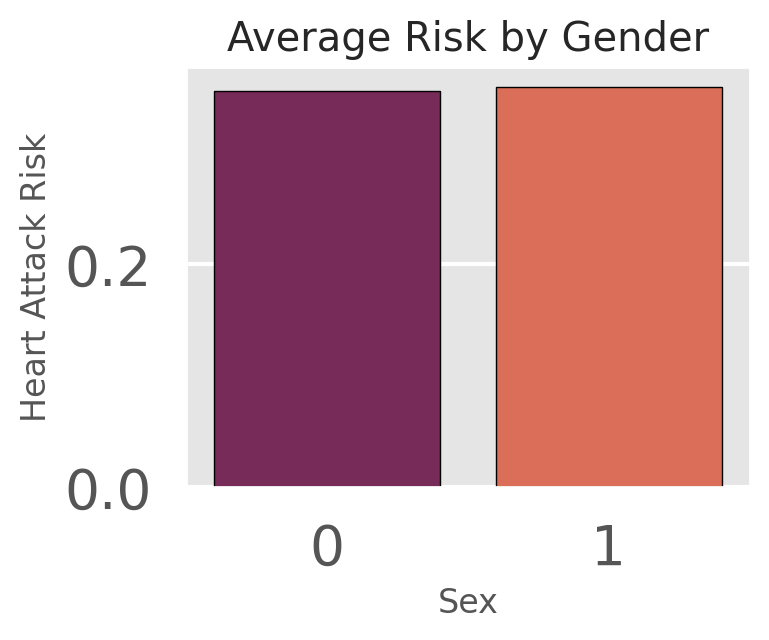

In [88]:
# 2. Gender vs Risk
# ------------------
plt.figure(figsize=(8, 6), dpi=200)  # Higher resolution

plt.subplot(2, 2, 2)
gender_risk = train.groupby('Sex')['Heart Attack Risk'].mean().reset_index()
sns.barplot(x='Sex', y='Heart Attack Risk', data=gender_risk,
            palette='rocket', edgecolor='black')
plt.title("Average Risk by Gender")

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Europe'),
  Text(1, 0, 'Asia'),
  Text(2, 0, 'Australia'),
  Text(3, 0, 'Africa'),
  Text(4, 0, 'South America'),
  Text(5, 0, 'North America')])

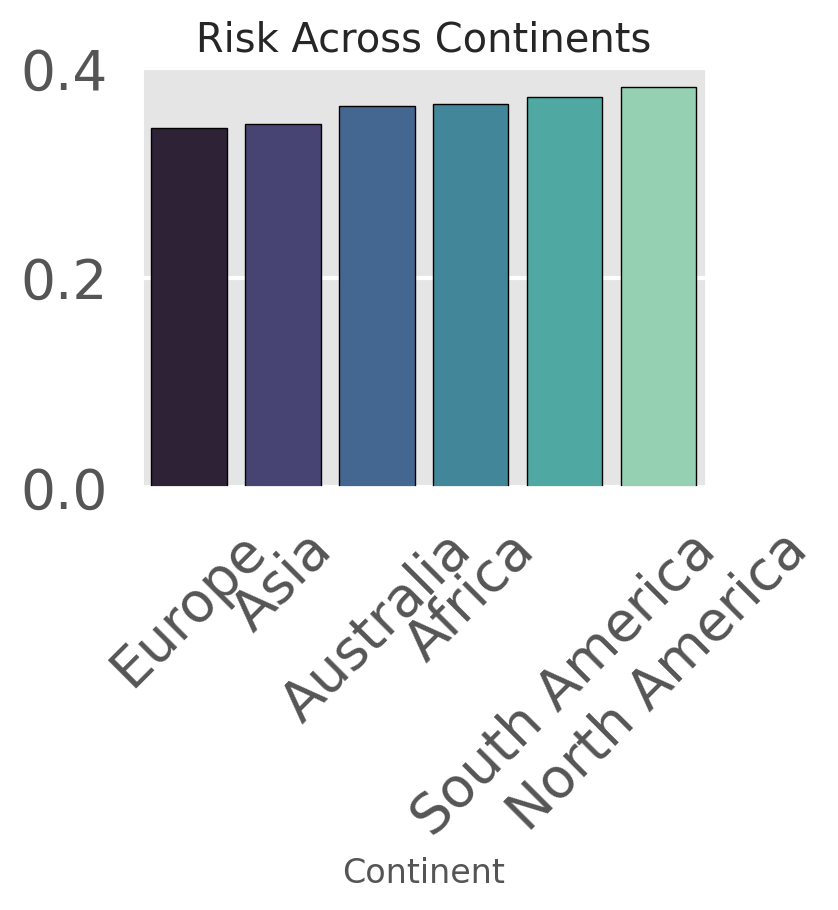

In [89]:
# 3. Continent Analysis
# ------------------
plt.figure(figsize=(8, 6), dpi=200)  # Higher resolution

plt.subplot(2, 2, 3)
continent_risk = train.groupby('Continent')['Heart Attack Risk'].mean().sort_values()
sns.barplot(x=continent_risk.index, y=continent_risk.values,
            palette='mako', edgecolor='black')
plt.title("Risk Across Continents")
plt.xticks(rotation=45)

In [90]:
sns.set_context("talk", font_scale=1.2)
palette = {0: "#2ecc71", 1: "#e74c3c"}  # Green=Low Risk, Red=High Risk



<Figure size 2400x1400 with 0 Axes>

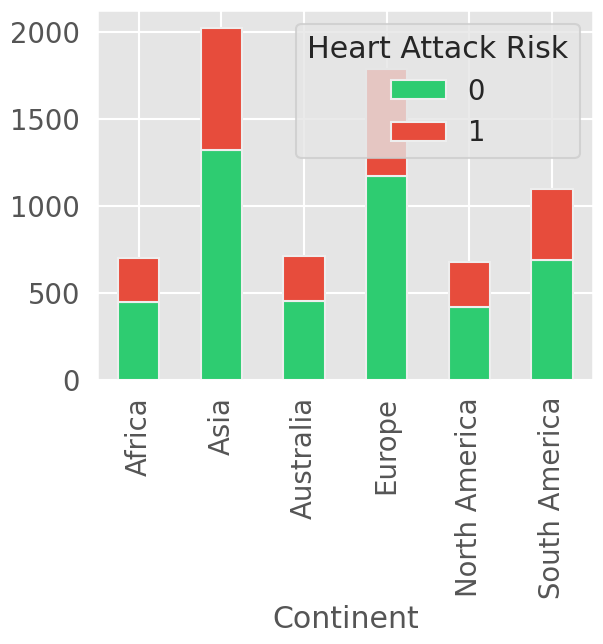

In [91]:
# 3. Continent Distribution (Separate Figure)
# ----------------------------------------------------------
plt.figure(figsize=(12, 7), dpi=200)  # Increased figure width for better label spacing

# Grouping the data by 'Continent' and 'Heart Attack Risk' and unstacking for plotting
continent_risk = train.groupby(['Continent', 'Heart Attack Risk']).size().unstack()

# Plotting the stacked bar chart
continent_risk.plot(kind='bar', stacked=True, color=[palette[0], palette[1]])

# Displaying the plot
plt.show()
# ----------------------------------------------------------

General Trends:

    1.High Risk in Asia: Significant health concern.
    2.Lower Risk in Africa and Australia: Better heart health or different risk factors.
    3.Moderate Risk in Europe, North America, and South America: Varying levels of risk.


## Age Group Distribution

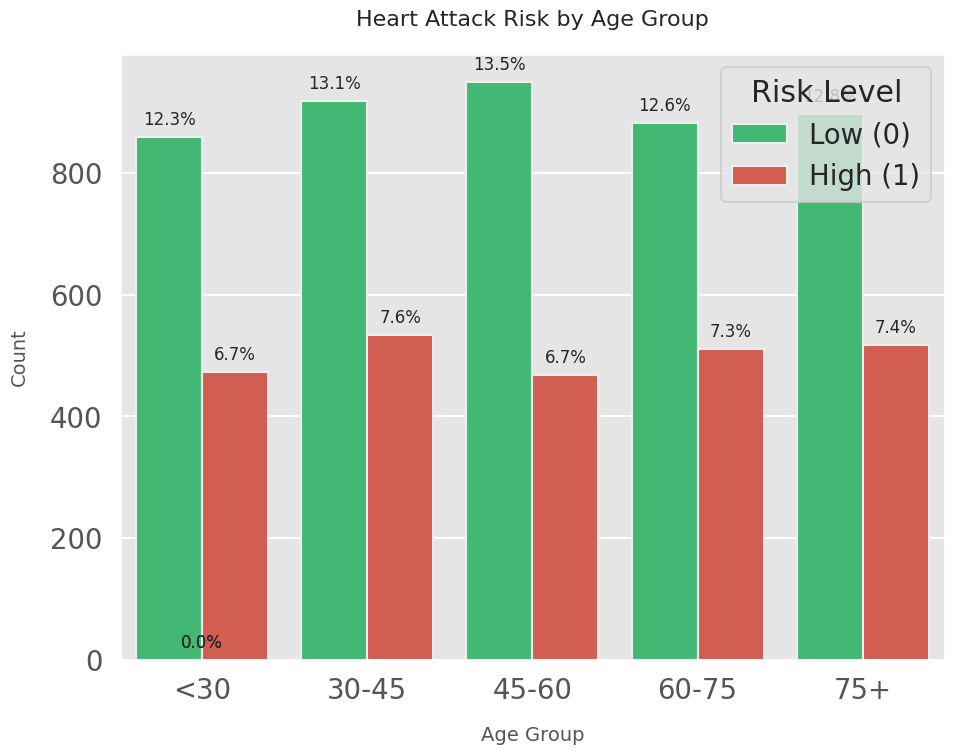

In [92]:
# ----------------------------------------------------------
# 1. Age Group Distribution (Separate Figure)
# ----------------------------------------------------------
plt.figure(figsize=(10, 8))
ax = sns.countplot(x='Age_Group', hue='Heart Attack Risk',
                  data=train, palette=palette)

plt.title("Heart Attack Risk by Age Group", pad=20, fontsize=16)
plt.xlabel("Age Group", labelpad=15, fontsize=14)
plt.ylabel("Count", labelpad=15, fontsize=14)
plt.legend(title="Risk Level", labels=["Low (0)", "High (1)"])

# Add percentage labels
total = len(train)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2., height + 20,
           f'{height/total:.1%}',
           ha='center', fontsize=12)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------

##### Heart attack risk increases with age, as the percentage of high-risk individuals (red bars) grows across age groups. The lowest risk is seen in those under 30, with no high-risk cases. The 30-75 age groups show a gradual rise in high-risk cases, peaking slightly in the 75+ group. Aging contributes to higher risk due to factors like weaker cardiovascular health, lifestyle accumulation effects, and higher prevalence of conditions like hypertension and diabetes.

## Gender Distribution

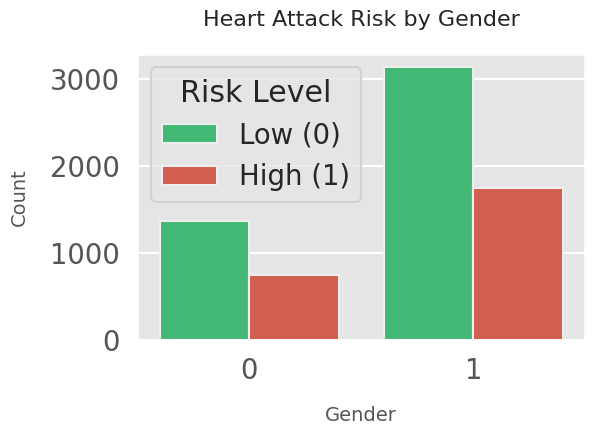

In [93]:
# 2. Gender Distribution (Separate Figure)
# ----------------------------------------------------------
ax = sns.countplot(x='Sex', hue='Heart Attack Risk',
                  data=train, palette=palette)

plt.title("Heart Attack Risk by Gender", pad=20, fontsize=16)
plt.xlabel("Gender", labelpad=15, fontsize=14)
plt.ylabel("Count", labelpad=15, fontsize=14)
plt.legend(title="Risk Level", labels=["Low (0)", "High (1)"])
plt.tight_layout()
plt.show()

# ----------------------------------------------------------


**Males have a higher heart attack risk than females, likely due to biological factors (lack of estrogen protection), lifestyle differences (higher smoking, alcohol, and stress levels), and healthcare behavior (less frequent check-ups). Preventive measures like healthier habits and regular screenings can help reduce the risk.**

## Smoking Status

In [94]:
train["Smoking"]

,Smoking
0,1
1,1
2,0
3,1
4,1
...,...
7005,0
7006,1
7007,1
7008,1


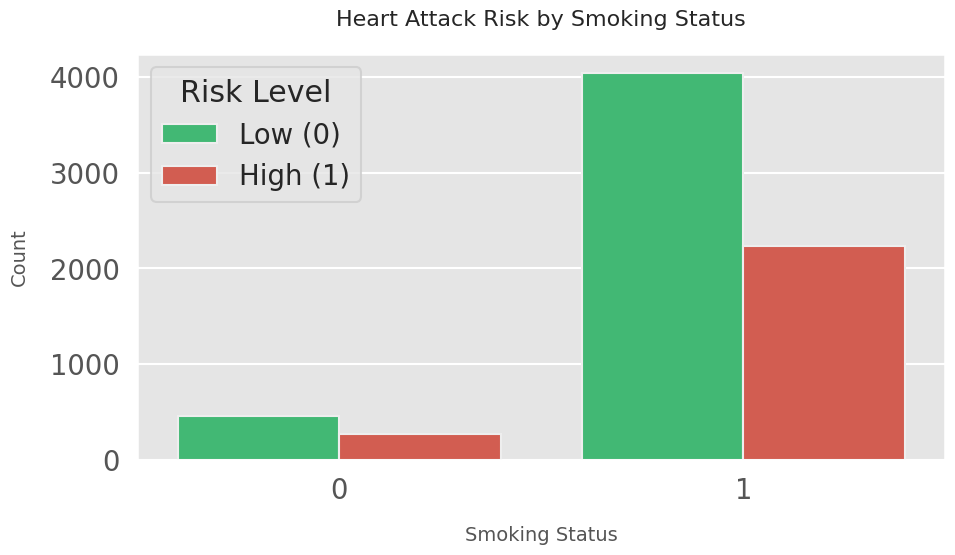

In [95]:
# 4. Smoking Status (Separate Figure)
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Smoking', hue='Heart Attack Risk',
                  data=train, palette=palette)

plt.title("Heart Attack Risk by Smoking Status", pad=20, fontsize=16)
plt.xlabel("Smoking Status", labelpad=15, fontsize=14)
plt.ylabel("Count", labelpad=15, fontsize=14)
plt.legend(title="Risk Level", labels=["Low (0)", "High (1)"])
plt.tight_layout()
plt.show()

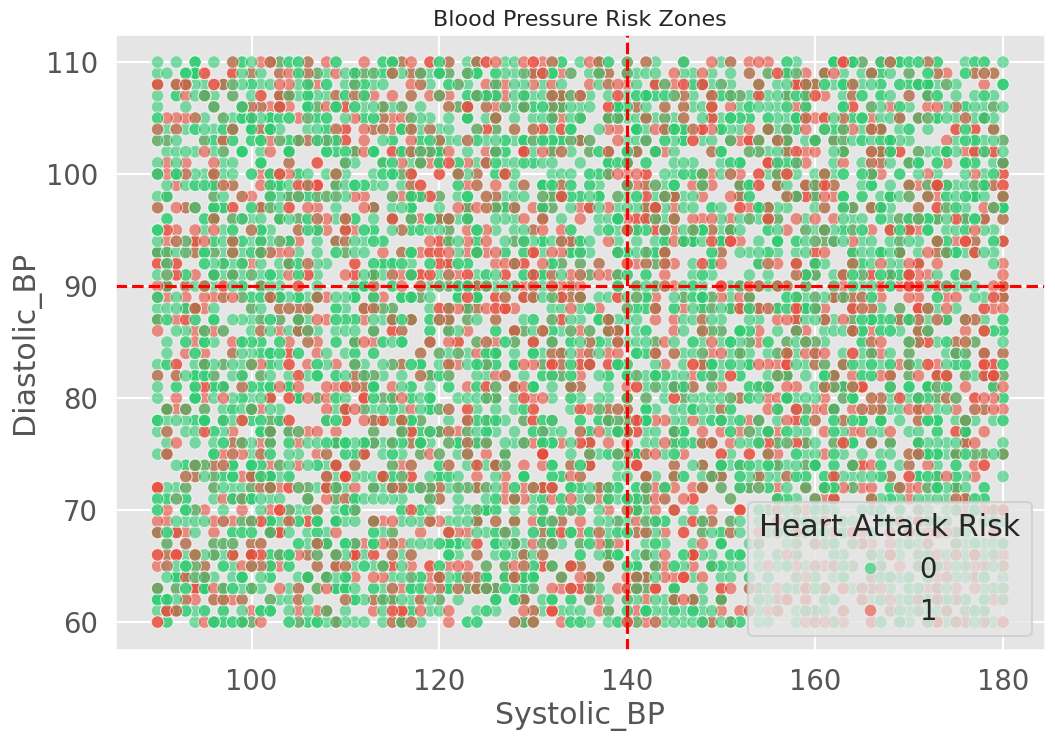

In [96]:
# Extract systolic/diastolic if not already done
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Systolic_BP', y='Diastolic_BP', hue='Heart Attack Risk',
                data=train, palette=palette, alpha=0.6)
plt.axvline(140, color='red', linestyle='--')  # Hypertension thresholds
plt.axhline(90, color='red', linestyle='--')
plt.title("Blood Pressure Risk Zones", fontsize=16)
plt.show()

## Sleep-Stress Relationship by Risk Status

<Figure size 1200x800 with 0 Axes>

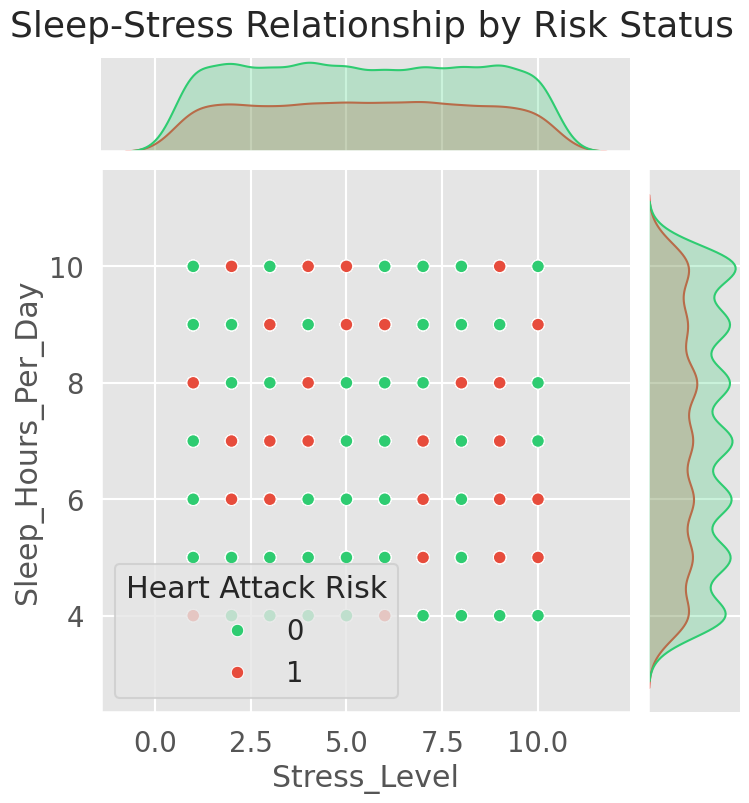

In [97]:
plt.figure(figsize=(12, 8))
sns.jointplot(x='Stress_Level', y='Sleep_Hours_Per_Day',
              data=train, hue='Heart Attack Risk',
              palette=palette, height=8)
plt.suptitle("Sleep-Stress Relationship by Risk Status", y=1.02)
plt.show()

## Lifestyle

<Figure size 700x700 with 0 Axes>

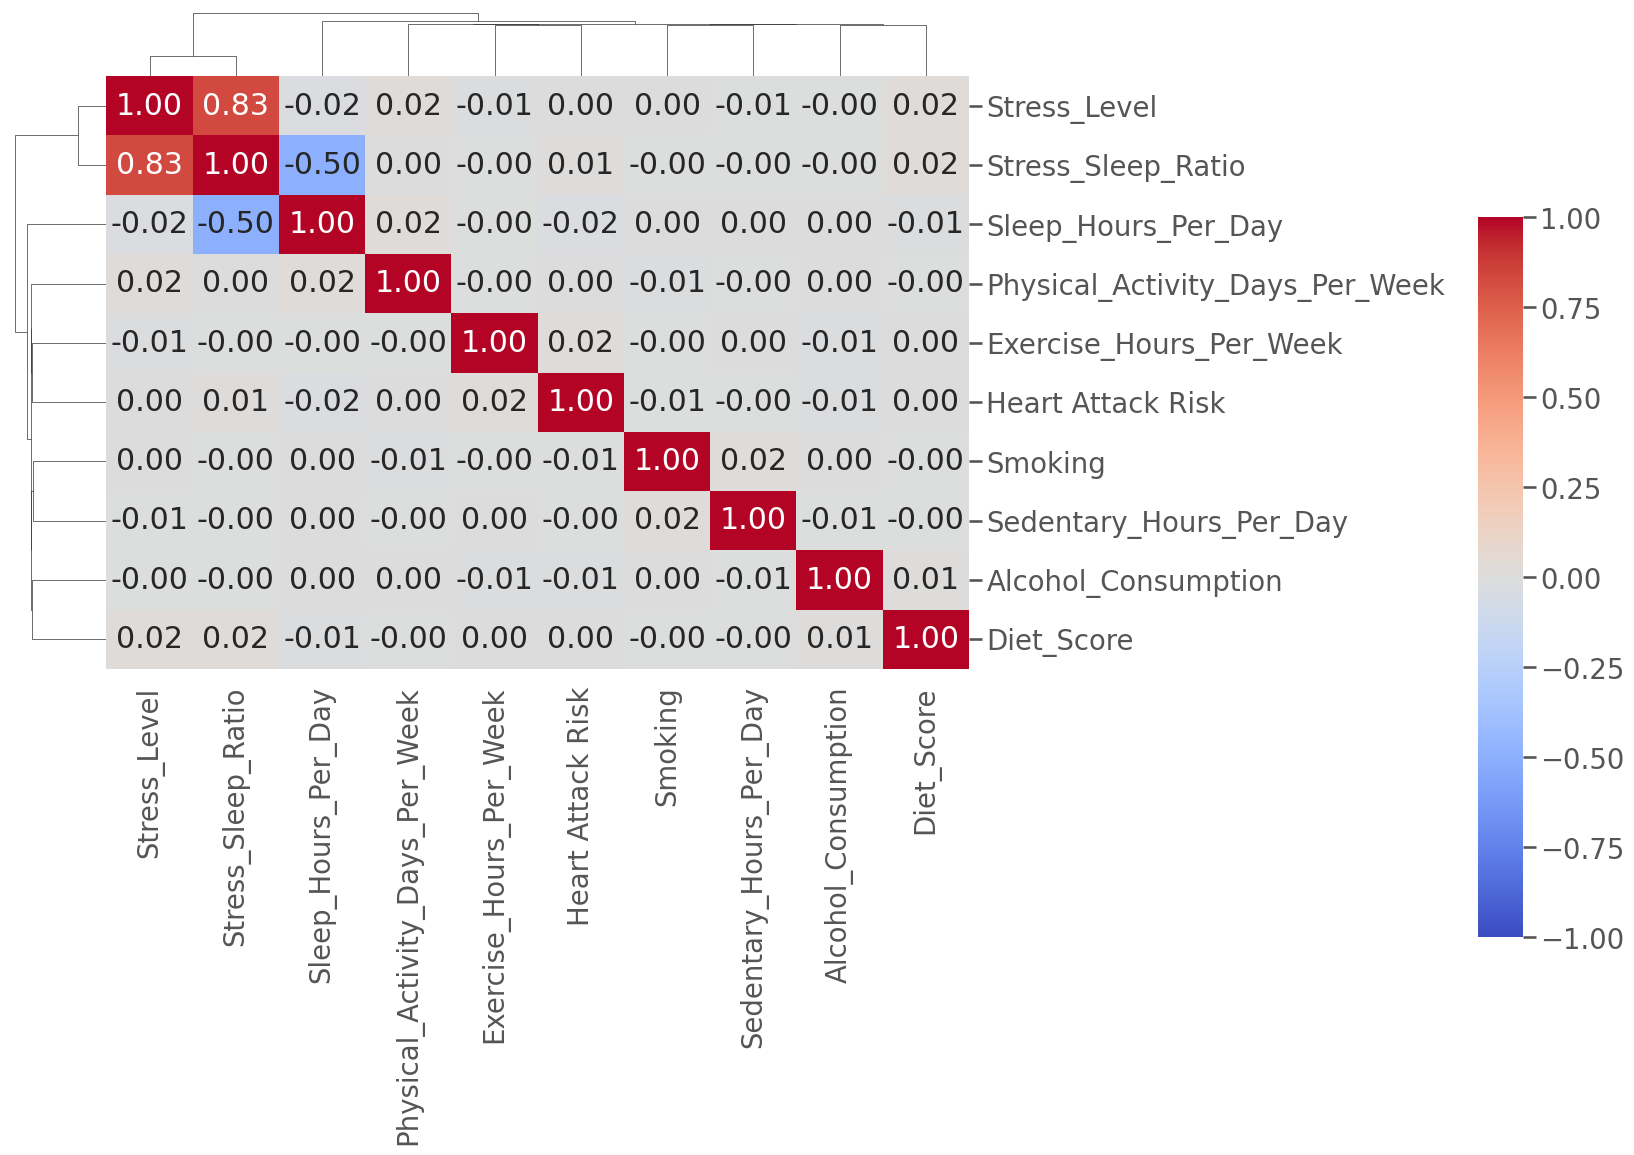

In [98]:
#Lifestyle
# Select and prepare lifestyle features
lifestyle_features = [
    'Smoking',
    'Alcohol_Consumption',
    'Exercise_Hours_Per_Week',
    'Sedentary_Hours_Per_Day',
    'Physical_Activity_Days_Per_Week',
    'Sleep_Hours_Per_Day',
    'Stress_Level',
    'Diet_Score',  # Your ordinal encoding
    'Stress_Sleep_Ratio',  # Your engineered feature
    'Heart Attack Risk'  # Target
]

# Calculate correlations
corr_matrix = train[lifestyle_features].corr()
plt.figure(figsize=(7, 7))

# Visualize with clustered heatmap
sns.clustermap(corr_matrix,
               annot=True,
               fmt=".2f",
               cmap='coolwarm',
               center=0,
               vmin=-1, vmax=1,
               row_cluster=True,
               col_cluster=True,
               dendrogram_ratio=(0.1, 0.1),  # Control dendrogram size
               cbar_pos=(1, 0.2, 0.03, 0.6),
               figsize=(15, 12))  # Set the figure size properly here

# Rotate labels for better readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()


## Medical Features Analysis

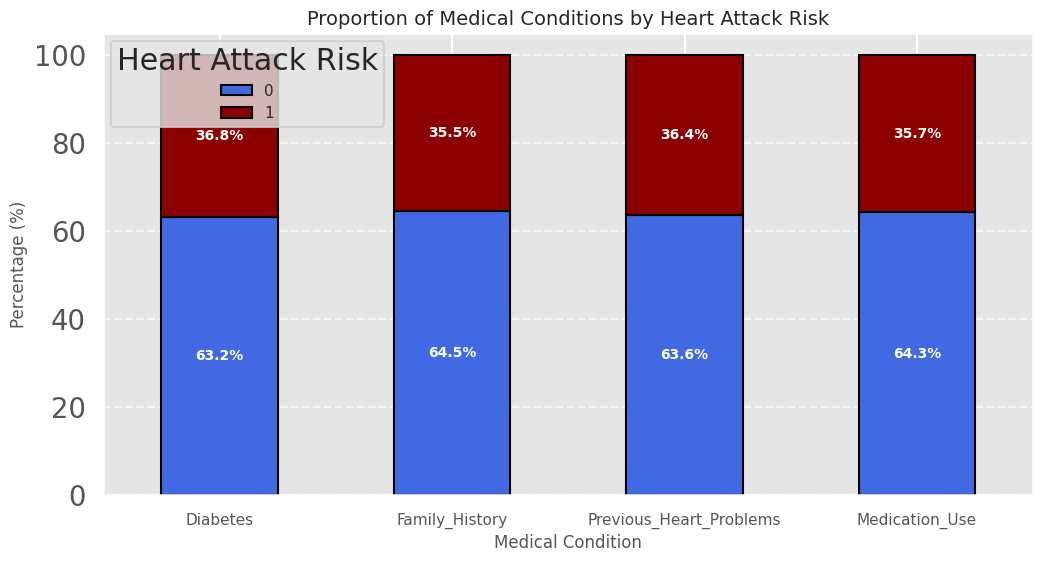

In [99]:

# Define medical features
medical_features = ['Diabetes', 'Family_History', 'Previous_Heart_Problems', 'Medication_Use']

# Count occurrences of each category
medical_summary = train.groupby('Heart Attack Risk')[medical_features].sum()

# Normalize per heart attack risk category
medical_summary = medical_summary.div(medical_summary.sum(axis=0), axis=1) * 100  # Normalize correctly

# Transpose for proper visualization
medical_summary = medical_summary.T

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['royalblue', 'darkred']
medical_summary.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors, edgecolor='black', ax=ax)

plt.title("Proportion of Medical Conditions by Heart Attack Risk", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xlabel("Medical Condition", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Heart Attack Risk", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Only label non-zero bars
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{height:.1f}%",  # Convert to percentage format
                    ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.show()


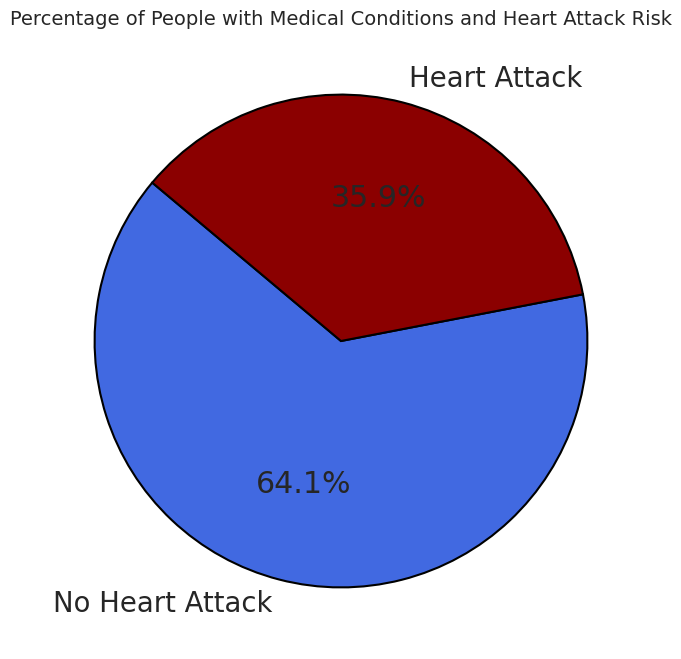

In [100]:
# Count total people with a medical condition and those with heart attack risk
total_with_condition = train['Has_Medical_Condition'].sum()  # Total with at least one condition
heart_attack_with_condition = train.loc[train['Has_Medical_Condition'] == 1, 'Heart Attack Risk'].sum()  # Sum of risk=1

# Compute percentages
if total_with_condition > 0:
    heart_attack_percentage = (heart_attack_with_condition / total_with_condition) * 100
    no_heart_attack_percentage = 100 - heart_attack_percentage
else:
    heart_attack_percentage = 0
    no_heart_attack_percentage = 100

# Ensure values are in a list (1D array)
values = [no_heart_attack_percentage, heart_attack_percentage]
labels = ['No Heart Attack', 'Heart Attack']

# Plot the pie chart
plt.figure(figsize=(8, 8))
colors = ['royalblue', 'darkred']
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title("Percentage of People with Medical Conditions and Heart Attack Risk", fontsize=14)

# Show the plot
plt.show()

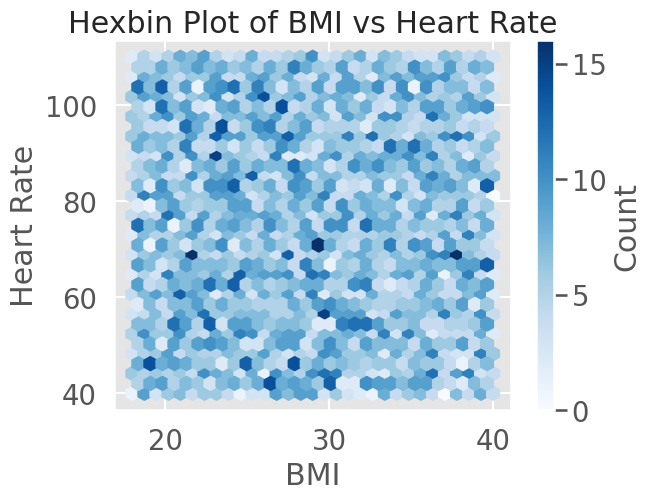

In [101]:
# Hexbin plot of BMI vs. Heart Rate
plt.hexbin(train['BMI'], train['Heart_Rate'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.title('Hexbin Plot of BMI vs Heart Rate')
plt.xlabel('BMI')
plt.ylabel('Heart Rate')
plt.show()


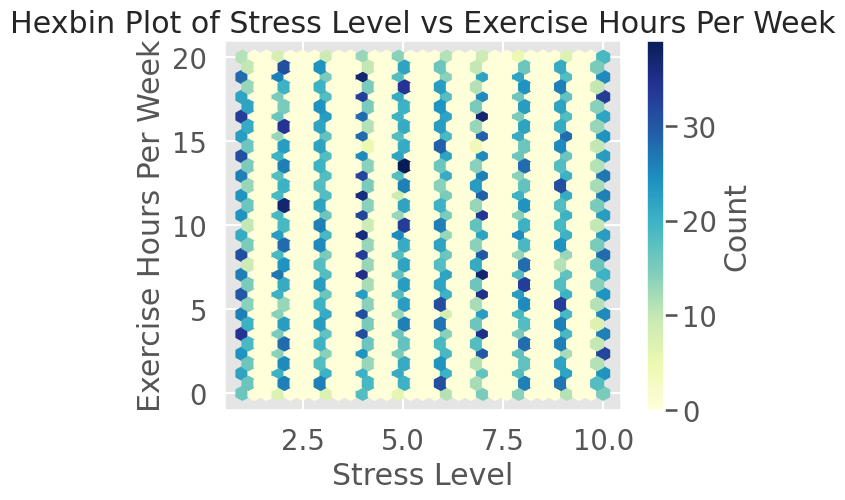

In [102]:
# Hexbin plot of Stress Level vs Exercise Hours Per Week
plt.hexbin(train['Stress_Level'], train['Exercise_Hours_Per_Week'], gridsize=30, cmap='YlGnBu')
plt.colorbar(label='Count')
plt.title('Hexbin Plot of Stress Level vs Exercise Hours Per Week')
plt.xlabel('Stress Level')
plt.ylabel('Exercise Hours Per Week')
plt.show()


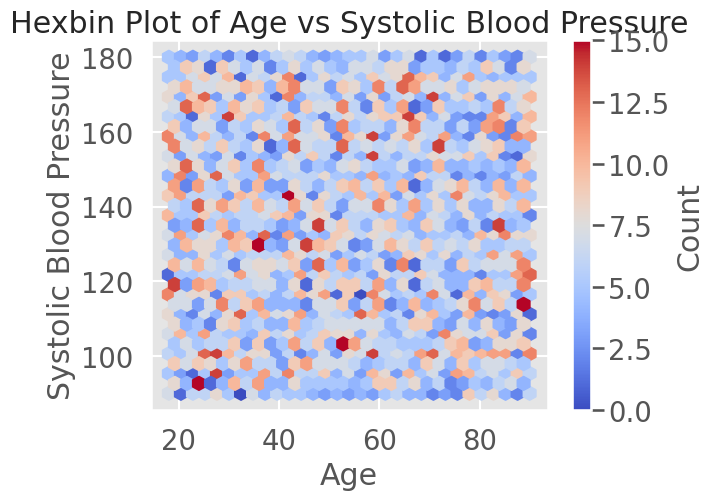

In [103]:
# Hexbin plot of Age vs Systolic Blood Pressure
plt.hexbin(train['Age'], train['Systolic_BP'], gridsize=30, cmap='coolwarm')
plt.colorbar(label='Count')
plt.title('Hexbin Plot of Age vs Systolic Blood Pressure')
plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure')
plt.show()


# <a id='toc1_3_2_'></a>[3.4 Hypothesis Testing](#toc0_)


In [104]:
train.columns

Index(['Patient_ID', 'Age', 'Sex', 'Cholesterol', 'Heart_Rate', 'Diabetes',
       'Family_History', 'Smoking', 'Obesity', 'Alcohol_Consumption',
       'Exercise_Hours_Per_Week', 'Previous_Heart_Problems', 'Medication_Use',
       'Stress_Level', 'Sedentary_Hours_Per_Day', 'Income', 'BMI',
       'Triglycerides', 'Physical_Activity_Days_Per_Week',
       'Sleep_Hours_Per_Day', 'Country', 'Continent', 'Hemisphere',
       'Systolic_BP', 'Diastolic_BP', 'Stress_Sleep_Ratio', 'Diet_Score',
       'Has_Medical_Condition', 'Physical_Mental_Health_Score',
       'Lifestyle_Risk_Score', 'Health_Risk_Score',
       'Physical_Mental_Health_Score_Category', 'Lifestyle_Risk_Category',
       'Age_Group', 'Risk_Category', 'Activity_Sedentary_Balance',
       'Heart Attack Risk'],
      dtype='object')

In [105]:
from scipy.stats import chi2_contingency
def chi_square_test(feature, target="Heart_Attack_Risk"):
    contingency_table = pd.crosstab(train[feature], train[target])
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    print(f"Chi-Square Test for {feature} vs. {target}:")
    print(f"Chi2-statistic = {chi2_stat:.4f}, p-value = {p_value:.4f}\n")

    if p_value < 0.05:
        print(f"Conclusion: There is a significant association between {feature} and {target}.\n")
    else:
        print(f"Conclusion: No significant association found between {feature} and {target}.\n")

## **Chi-Square Test: Assessing the Relationship Between Physical & Mental Health and Heart Attack Risk**
This analysis examines whether there is a **statistical association** between **Physical & Mental Health Score** (derived from stress, sedentary hours, and exercise) and **Heart Attack Risk**.  

- **Null Hypothesis (\(H_0\))**: No significant relationship exists between the two variables.  
- **Alternative Hypothesis (\(H_A\))**: There is a significant relationship between Physical & Mental Health Score and Heart Attack Risk.  

A **Chi-Square test** is performed on the contingency table. If \( p < 0.05 \), we reject \(H_0\), indicating a meaningful association between health status and heart attack risk.



**The Physical & Mental Health Score** is introduced to create a single metric summarizing key lifestyle and psychological factors affecting overall well-being. By combining stress level, sedentary behavior, and exercise, this feature helps identify patterns and correlations with heart attack risk, making analysis and model interpretation more intuitive.
Choice of Coefficients

The coefficients are assigned based on the expected impact of each factor on overall health:

    Stress Level (+0.317): Chronic stress negatively affects both mental and cardiovascular health, making it a strong contributor.

    Sedentary Hours Per Day (+0.268): A sedentary lifestyle is associated with increased health risks, but its impact is slightly lower than stress.

    Exercise Hours Per Week (-0.415): Regular exercise significantly improves both physical and mental well-being, so it has a negative weight, indicating a protective effect.

The coefficients are normalized to keep the score on a consistent scale while maintaining the relative importance of each factor.

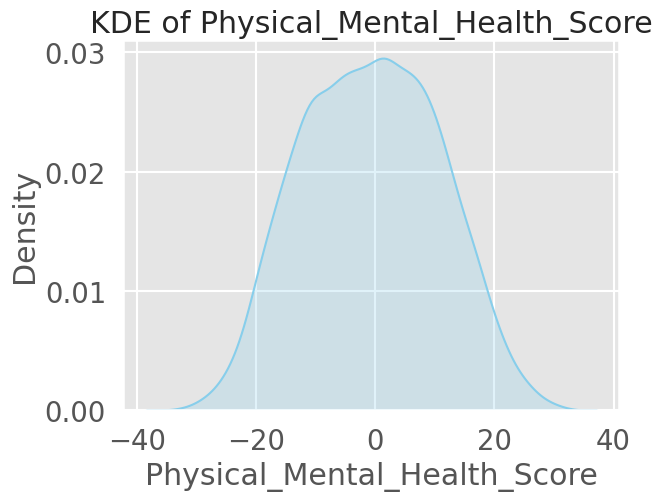

In [106]:
# Plot KDE
sns.kdeplot(train["Physical_Mental_Health_Score"], shade=True, color='skyblue')
plt.xlabel('Physical_Mental_Health_Score')
plt.ylabel('Density')
plt.title('KDE of Physical_Mental_Health_Score')
plt.show()


In [107]:
train.columns

Index(['Patient_ID', 'Age', 'Sex', 'Cholesterol', 'Heart_Rate', 'Diabetes',
       'Family_History', 'Smoking', 'Obesity', 'Alcohol_Consumption',
       'Exercise_Hours_Per_Week', 'Previous_Heart_Problems', 'Medication_Use',
       'Stress_Level', 'Sedentary_Hours_Per_Day', 'Income', 'BMI',
       'Triglycerides', 'Physical_Activity_Days_Per_Week',
       'Sleep_Hours_Per_Day', 'Country', 'Continent', 'Hemisphere',
       'Systolic_BP', 'Diastolic_BP', 'Stress_Sleep_Ratio', 'Diet_Score',
       'Has_Medical_Condition', 'Physical_Mental_Health_Score',
       'Lifestyle_Risk_Score', 'Health_Risk_Score',
       'Physical_Mental_Health_Score_Category', 'Lifestyle_Risk_Category',
       'Age_Group', 'Risk_Category', 'Activity_Sedentary_Balance',
       'Heart Attack Risk'],
      dtype='object')

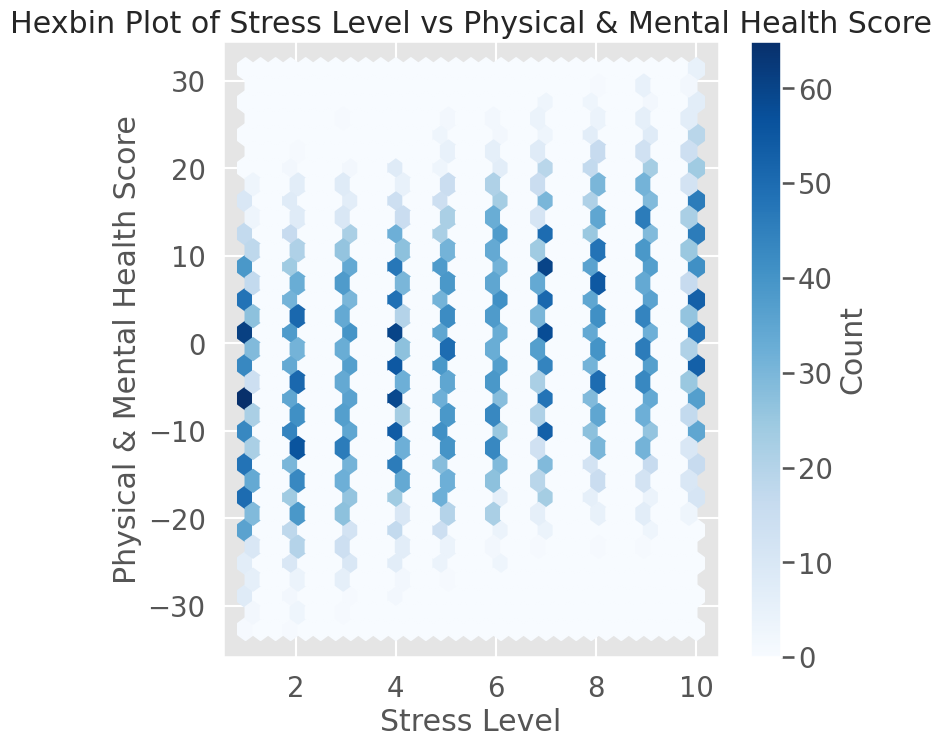

In [108]:
plt.figure(figsize=(8, 8))
plt.hexbin(train['Stress_Level'], train['Physical_Mental_Health_Score'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.title('Hexbin Plot of Stress Level vs Physical & Mental Health Score')
plt.xlabel('Stress Level')
plt.ylabel('Physical & Mental Health Score')
plt.show()


In [109]:
# Create a DataFrame containing only the relevant columns
df1 = pd.DataFrame({
    'Physical_Mental_Health_Score_Category': train['Physical_Mental_Health_Score_Category'],
    'Heart Attack Risk': y
})

# Create the contingency table
contingency_table = pd.crosstab(df1['Physical_Mental_Health_Score_Category'], df1['Heart Attack Risk'])

print("Contingency Table:")
print(contingency_table)

# Perform the Chi-Square Test on the contingency table
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test Results:")
print("Chi2 statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Contingency Table:
Heart Attack Risk                         0     1
Physical_Mental_Health_Score_Category            
Low                                    2305  1336
High                                   2201  1168

Chi-Square Test Results:
Chi2 statistic: 3.0350210605456356
p-value: 0.08148549215868993
Degrees of freedom: 1


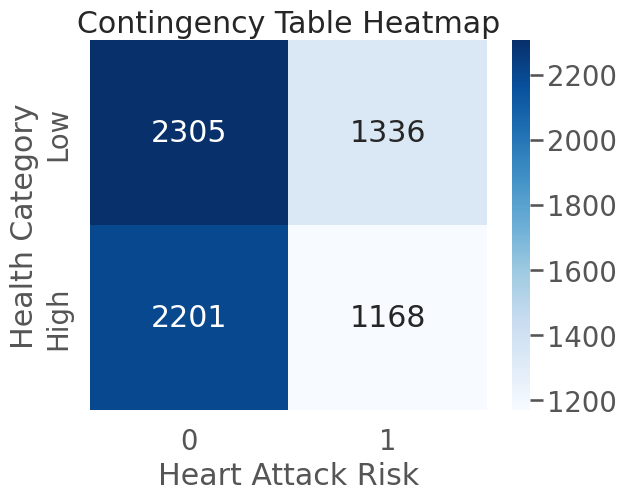

In [110]:
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt="d")
plt.title("Contingency Table Heatmap")
plt.xlabel("Heart Attack Risk")
plt.ylabel("Health Category")
plt.show()


The **Lifestyle Risk Score** is a composite feature designed to quantify an individual's lifestyle risk based on several factors:

- **Smoking (weight 2)**: Smoking significantly increases health risks, so it is assigned the highest weight.
- **Obesity (BMI > 30, weight 1)**: Obesity is a major risk factor for various health issues, given a moderate weight.
- **Alcohol Consumption (weight 1)**: Alcohol consumption contributes to health risks, assigned a moderate weight.
- **Exercise Hours per Week (weight -1)**: Regular exercise lowers health risks, so it receives a negative weight.
- **Diet Score (weight -2)**: A higher diet score indicates better dietary habits, and thus, a negative weight reflects its protective effect.

This score combines these factors to assess overall lifestyle risk, where higher scores indicate higher risk.

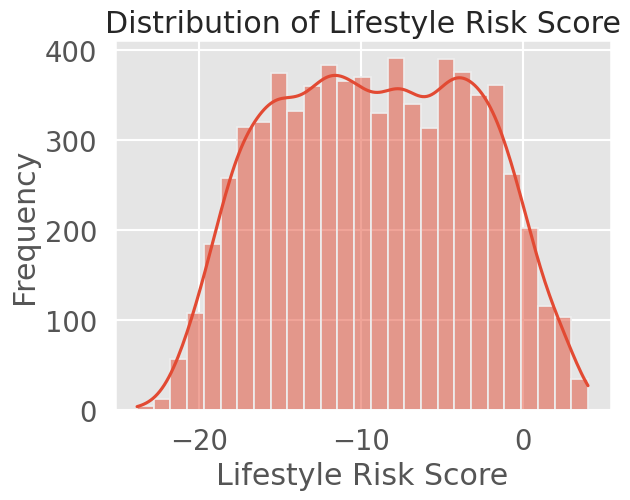

In [111]:
sns.histplot(train['Lifestyle_Risk_Score'], kde=True)
plt.title('Distribution of Lifestyle Risk Score')
plt.xlabel('Lifestyle Risk Score')
plt.ylabel('Frequency')
plt.show()

In [112]:
from scipy.stats import pointbiserialr

# Calculate Point-Biserial correlation between Heart_Attack_Risk and Health_Risk_Score
correlation, p_value = pointbiserialr(train['Heart Attack Risk'], train['Lifestyle_Risk_Score'])

# Print results
print(f"Point-Biserial Correlation: {correlation}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a significant correlation between Heart Attack Risk and Lifestyle_Risk_Score.")
else:
    print("There is no significant correlation between Heart Attack Risk and Lifestyle_Risk_Score.")


Point-Biserial Correlation: -0.016992015010665586
P-value: 0.15487591201643433
There is no significant correlation between Heart Attack Risk and Lifestyle_Risk_Score.


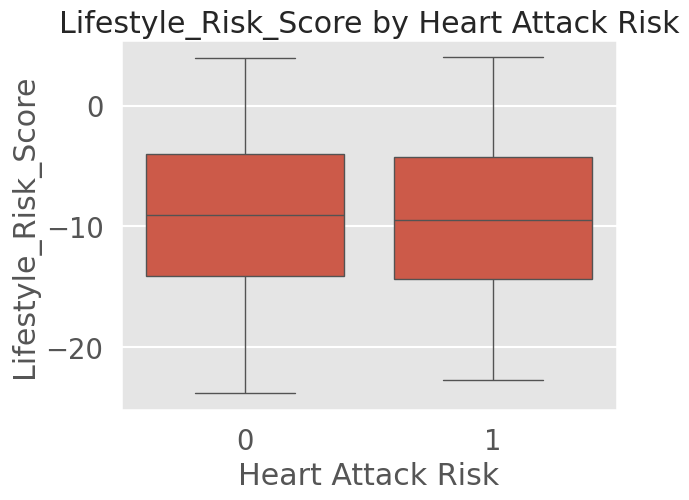

In [113]:
# Box plot to compare Health_Risk_Score by Heart_Attack_Risk
sns.boxplot(x='Heart Attack Risk', y='Lifestyle_Risk_Score', data=train)
plt.title('Lifestyle_Risk_Score by Heart Attack Risk')
plt.xlabel('Heart Attack Risk')
plt.ylabel('Lifestyle_Risk_Score')
plt.show()


In [114]:
# Step 2: Create a contingency table between Risk_Category and Heart_Attack_Risk.
contingency_table = pd.crosstab(train['Lifestyle_Risk_Category'], train['Heart Attack Risk'])
print("Contingency Table:")
print(contingency_table)

# Step 3: Perform the Chi-Square Test on the contingency table.
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test Results:")
print("Chi2 statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)


Contingency Table:
Heart Attack Risk           0     1
Lifestyle_Risk_Category            
Low                      2038  1197
High                     2468  1307

Chi-Square Test Results:
Chi2 statistic: 4.191222494274707
p-value: 0.040633785738122395
Degrees of freedom: 1
Expected frequencies:
 [[2079.44507846 1155.55492154]
 [2426.55492154 1348.44507846]]


plt.figure(figsize=(8, 8))

sns.swarmplot(x='Lifestyle_Risk_Category', y='Physical_Mental_Health_Score', data=train)
plt.title('Swarm Plot of Physical & Mental Health Score by Lifestyle Risk Category')
plt.xlabel('Lifestyle Risk Category')
plt.ylabel('Physical & Mental Health Score')
plt.show()


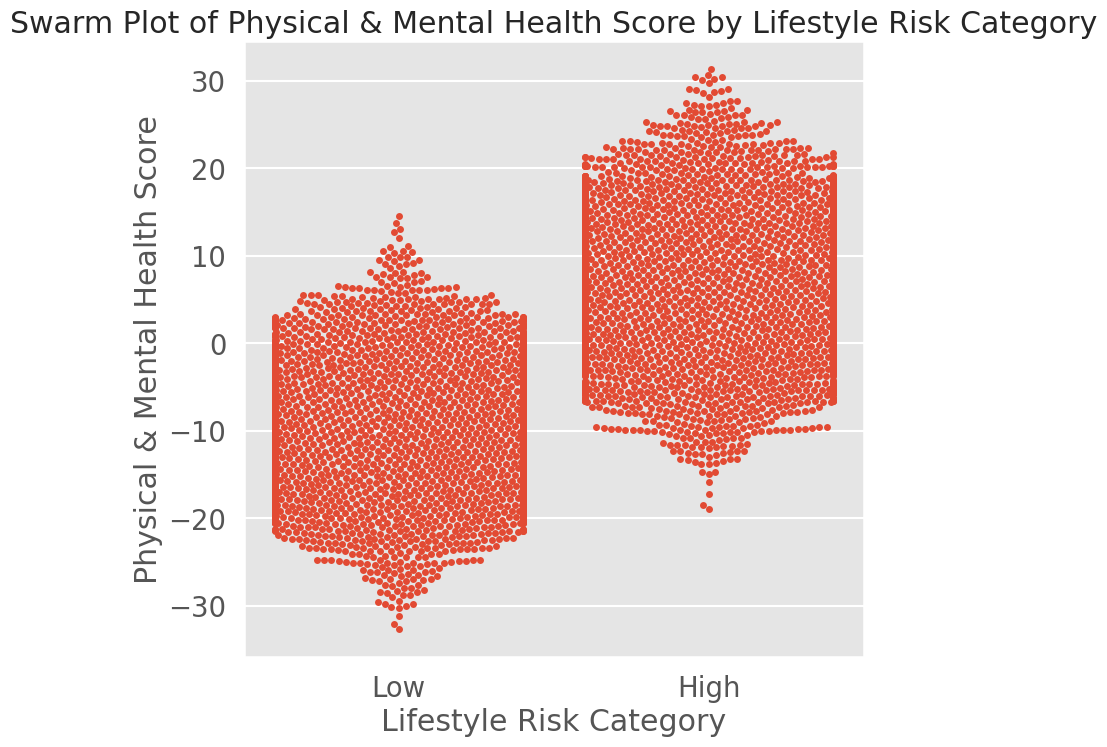

In [115]:
plt.figure(figsize=(8, 8))

sns.swarmplot(x='Lifestyle_Risk_Category', y='Physical_Mental_Health_Score', data=train)
plt.title('Swarm Plot of Physical & Mental Health Score by Lifestyle Risk Category')
plt.xlabel('Lifestyle Risk Category')
plt.ylabel('Physical & Mental Health Score')
plt.show()


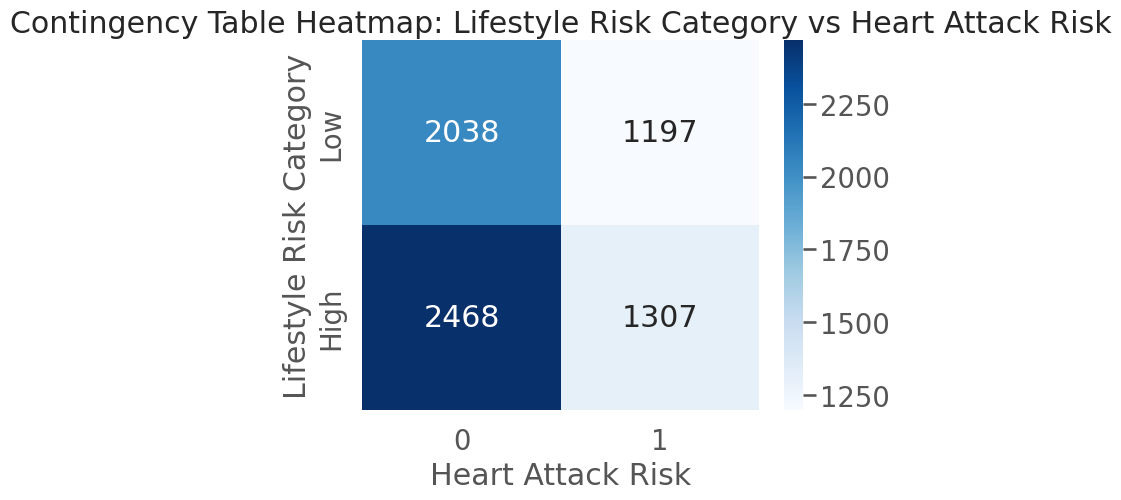

In [116]:
# Plot heatmap
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt="d")
plt.title("Contingency Table Heatmap: Lifestyle Risk Category vs Heart Attack Risk")
plt.xlabel("Heart Attack Risk")
plt.ylabel("Lifestyle Risk Category")
plt.show()


In [117]:
# Create a contingency table
contingency_table = pd.crosstab(train['Obesity'], train['Heart Attack Risk'])

# Perform the Chi-Square Test for Independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Print results
print(f"Chi-Square Statistic = {chi2_stat:.4f}")
print(f"P-value = {p_value:.4f}")
print(f"Degrees of Freedom = {dof}")
print(f"Expected Frequencies Table:\n{expected}")

# Conclusion
if p_value < 0.05:
    print("""Conclusion: There is a significant association between
    obesity and heart attack risk.""")
else:
    print("Conclusion: No significant association between obesity and heart attack risk.")

Chi-Square Statistic = 1.0083
P-value = 0.3153
Degrees of Freedom = 1
Expected Frequencies Table:
[[2253.64279601 1252.35720399]
 [2252.35720399 1251.64279601]]
Conclusion: No significant association between obesity and heart attack risk.


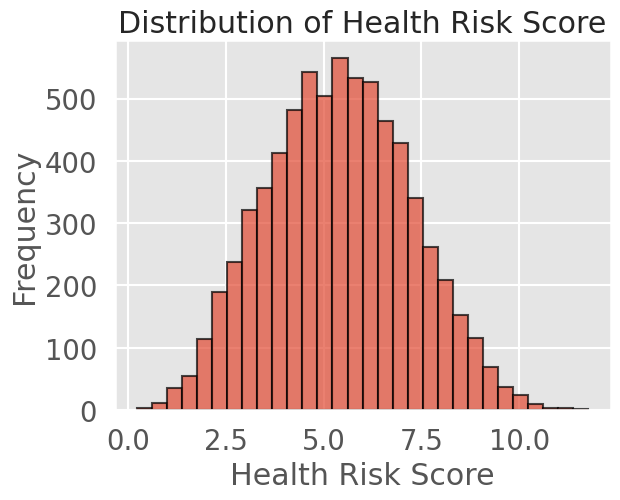

In [118]:
plt.hist(train['Health_Risk_Score'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Health Risk Score')
plt.xlabel('Health Risk Score')
plt.ylabel('Frequency')
plt.show()


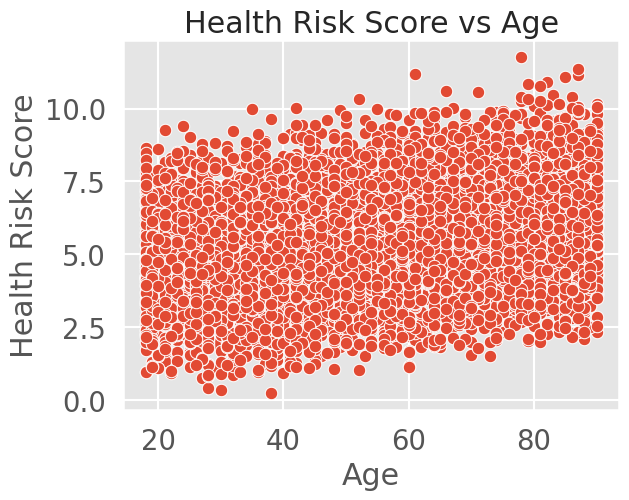

In [119]:
sns.scatterplot(x='Age', y='Health_Risk_Score', data=train)
plt.title('Health Risk Score vs Age')
plt.xlabel('Age')
plt.ylabel('Health Risk Score')
plt.show()


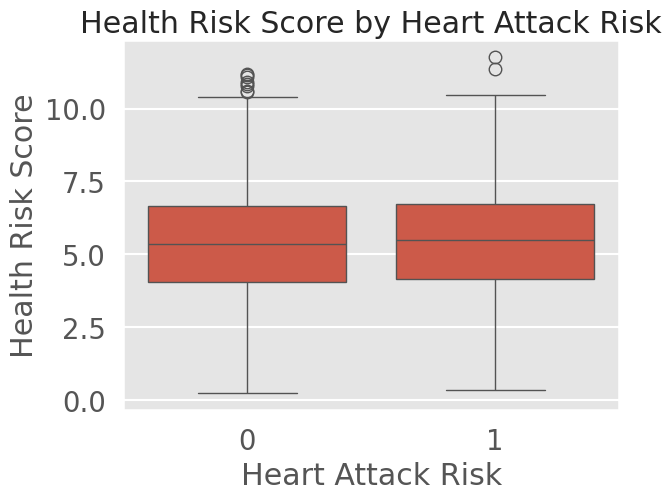

In [120]:
sns.boxplot(x='Heart Attack Risk', y='Health_Risk_Score', data=train)
plt.title('Health Risk Score by Heart Attack Risk')
plt.xlabel('Heart Attack Risk')
plt.ylabel('Health Risk Score')
plt.show()


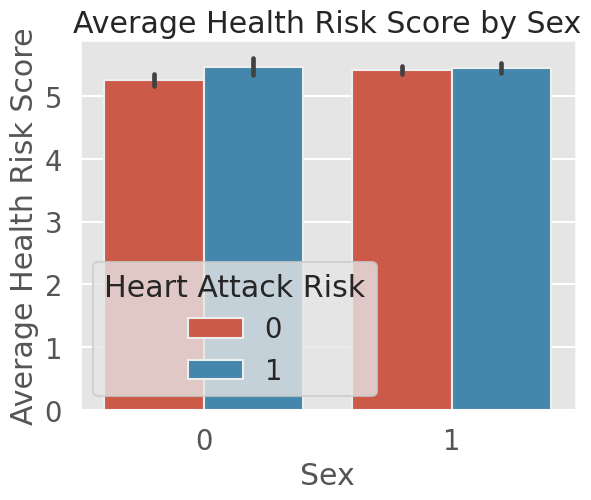

In [121]:
sns.barplot(x='Sex', y='Health_Risk_Score', data=train,hue="Heart Attack Risk")
plt.title('Average Health Risk Score by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Health Risk Score')
plt.show()


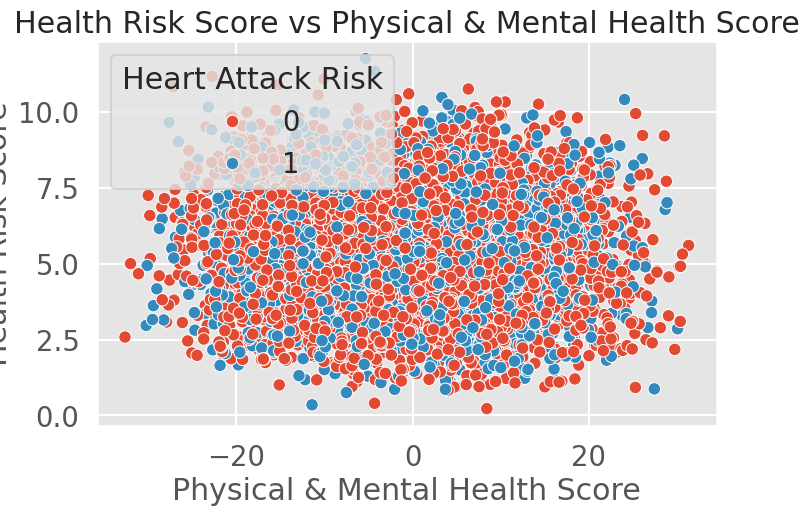

In [122]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Physical_Mental_Health_Score', y='Health_Risk_Score', data=train,hue="Heart Attack Risk")
plt.title('Health Risk Score vs Physical & Mental Health Score')
plt.xlabel('Physical & Mental Health Score')
plt.ylabel('Health Risk Score')
plt.show()


In [123]:
import scipy.stats as stats

# Group data based on Heart_Attack_Risk (0 and 1)
group_0 = train[train['Heart Attack Risk'] == 0]['Health_Risk_Score']
group_1 = train[train['Heart Attack Risk'] == 1]['Health_Risk_Score']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(group_0, group_1)

# Print results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Check if p-value is less than the significance level (0.05)
if p_value < 0.05:
    print("There is a significant difference in Health Risk Score between the two Heart Attack Risk groups.")
else:
    print("There is no significant difference in Health Risk Score between the two Heart Attack Risk groups.")


T-statistic: -1.7879527740724217
P-value: 0.07382681823006365
There is no significant difference in Health Risk Score between the two Heart Attack Risk groups.


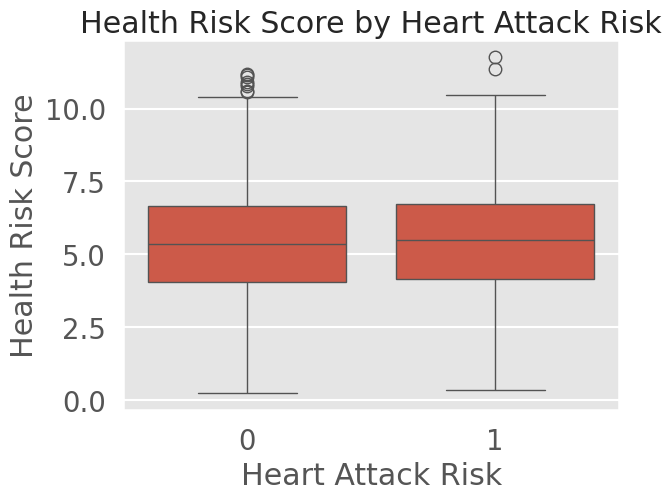

In [124]:

# Box plot for Health_Risk_Score by Heart_Attack_Risk
sns.boxplot(x='Heart Attack Risk', y='Health_Risk_Score', data=train)
plt.title('Health Risk Score by Heart Attack Risk')
plt.xlabel('Heart Attack Risk')
plt.ylabel('Health Risk Score')
plt.show()


In [125]:
# Verify distribution
print(train['Risk_Category'].value_counts())
# Step 2: Create contingency table
contingency_table = pd.crosstab(
    train['Risk_Category'],
    train['Heart Attack Risk'],
    margins=True
)
print("\nContingency Table:")
print(contingency_table)

# Step 3: Chi-Square Test (remove 'All' margins for the test)
chi2, p_value, dof, expected = chi2_contingency(contingency_table.iloc[:-1, :-1])

print("\nChi-Square Test Results:")
print(f"Chi2 Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

Risk_Category
Medium    4105
High      2210
Low        695
Name: count, dtype: int64

Contingency Table:
Heart Attack Risk     0     1   All
Risk_Category                      
Low                 450   245   695
Medium             2668  1437  4105
High               1388   822  2210
All                4506  2504  7010

Chi-Square Test Results:
Chi2 Statistic: 3.07
P-value: 0.2154
Degrees of Freedom: 2
Expected Frequencies:
 [[ 446.74322397  248.25677603]
 [2638.67760342 1466.32239658]
 [1420.57917261  789.42082739]]


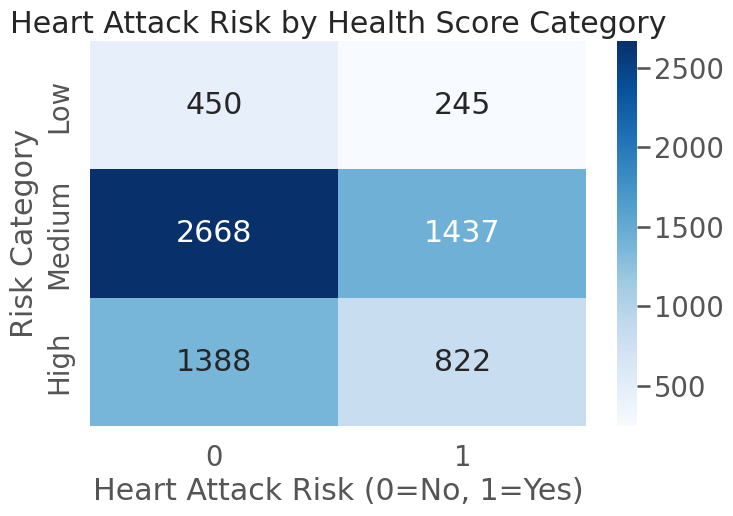

In [126]:
# Stacked bar plot
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_table.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues')
plt.title("Heart Attack Risk by Health Score Category")
plt.xlabel("Heart Attack Risk (0=No, 1=Yes)")
plt.ylabel("Risk Category")
plt.show()

In [127]:
from scipy.stats import f_oneway

# Group data based on Heart_Attack_Risk (0 and 1)
group_0 = train[train['Heart Attack Risk'] == 0]['Health_Risk_Score']
group_1 = train[train['Heart Attack Risk'] == 1]['Health_Risk_Score']

# Perform one-way ANOVA
f_stat, p_value = f_oneway(group_0, group_1)

# Print results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a significant difference in Health Risk Score between the two Heart Attack Risk groups (ANOVA).")
else:
    print("There is no significant difference in Health Risk Score between the two Heart Attack Risk groups (ANOVA).")


F-statistic: 3.1967751223132344
P-value: 0.07382681823039518
There is no significant difference in Health Risk Score between the two Heart Attack Risk groups (ANOVA).


In [128]:
from scipy.stats import pointbiserialr

# Calculate Point-Biserial correlation between Heart_Attack_Risk and Health_Risk_Score
correlation, p_value = pointbiserialr(train['Heart Attack Risk'], train['Health_Risk_Score'])

# Print results
print(f"Point-Biserial Correlation: {correlation}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a significant correlation between Heart Attack Risk and Health Risk Score.")
else:
    print("There is no significant correlation between Heart Attack Risk and Health Risk Score.")


Point-Biserial Correlation: 0.02135305237742726
P-value: 0.07382681823006543
There is no significant correlation between Heart Attack Risk and Health Risk Score.


In [129]:
train.columns

Index(['Patient_ID', 'Age', 'Sex', 'Cholesterol', 'Heart_Rate', 'Diabetes',
       'Family_History', 'Smoking', 'Obesity', 'Alcohol_Consumption',
       'Exercise_Hours_Per_Week', 'Previous_Heart_Problems', 'Medication_Use',
       'Stress_Level', 'Sedentary_Hours_Per_Day', 'Income', 'BMI',
       'Triglycerides', 'Physical_Activity_Days_Per_Week',
       'Sleep_Hours_Per_Day', 'Country', 'Continent', 'Hemisphere',
       'Systolic_BP', 'Diastolic_BP', 'Stress_Sleep_Ratio', 'Diet_Score',
       'Has_Medical_Condition', 'Physical_Mental_Health_Score',
       'Lifestyle_Risk_Score', 'Health_Risk_Score',
       'Physical_Mental_Health_Score_Category', 'Lifestyle_Risk_Category',
       'Age_Group', 'Risk_Category', 'Activity_Sedentary_Balance',
       'Heart Attack Risk'],
      dtype='object')

In [130]:
# Create a contingency table
contingency_table = pd.crosstab(train['Alcohol_Consumption'], train['Heart Attack Risk'])

# Perform Chi-Square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Print results
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.4f}")

# Interpret the p-value
alpha = 0.05  # or 0.08 if you decide to use it
if p_value < alpha:
    print("Reject the null hypothesis: Alcohol consumption is significantly associated with heart attack risk.")
else:
    print("Fail to reject the null hypothesis: No significant association between alcohol consumption and heart attack risk.")

Chi-Square Statistic: 0.6231
Degrees of Freedom: 1
P-value: 0.4299
Fail to reject the null hypothesis: No significant association between alcohol consumption and heart attack risk.


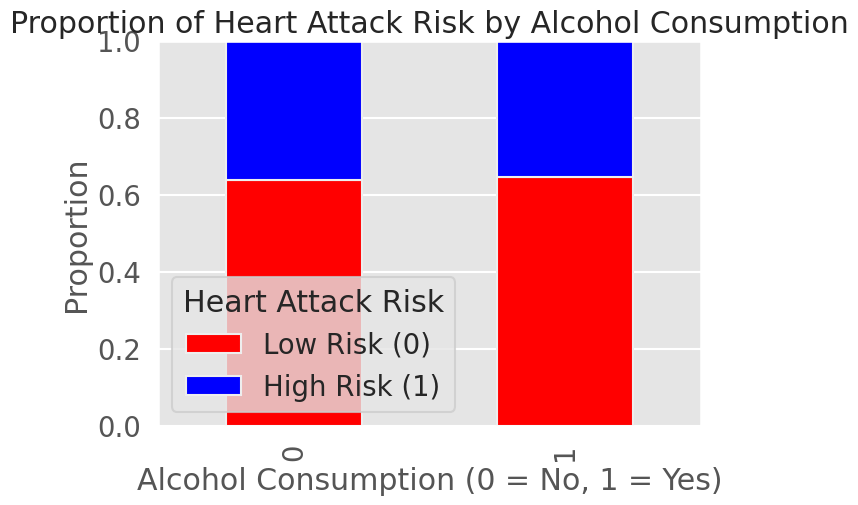

In [131]:
# Create a normalized (percentage-based) contingency table
contingency_table = pd.crosstab(train["Alcohol_Consumption"], train["Heart Attack Risk"], normalize="index")

# Plot the stacked bar chart
contingency_table.plot(kind="bar", stacked=True, color=["red", "blue"], figsize=(7,5))

# Formatting the plot

plt.title("Proportion of Heart Attack Risk by Alcohol Consumption")
plt.xlabel("Alcohol Consumption (0 = No, 1 = Yes)")
plt.ylabel("Proportion")
plt.legend(title="Heart Attack Risk", labels=["Low Risk (0)", "High Risk (1)"])
plt.ylim(0, 1)  # Ensures proportions range from 0 to 1
plt.show()

In [132]:
# Create a contingency table
contingency_table = pd.crosstab(train['Smoking'], train['Heart Attack Risk'])

# Perform Chi-Square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Print results
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Interpretation
if p_value < 0.05:
    print("There is a significant association between Smoking and Heart Attack Risk.")
else:
    print("There is no significant association between Smoking and Heart Attack Risk.")

Chi-Square Statistic: 0.1548
P-value: 0.6940
Degrees of Freedom: 1
Expected Frequencies Table:
Heart Attack Risk            0            1
Smoking                                    
0                   467.312696   259.687304
1                  4038.687304  2244.312696
There is no significant association between Smoking and Heart Attack Risk.


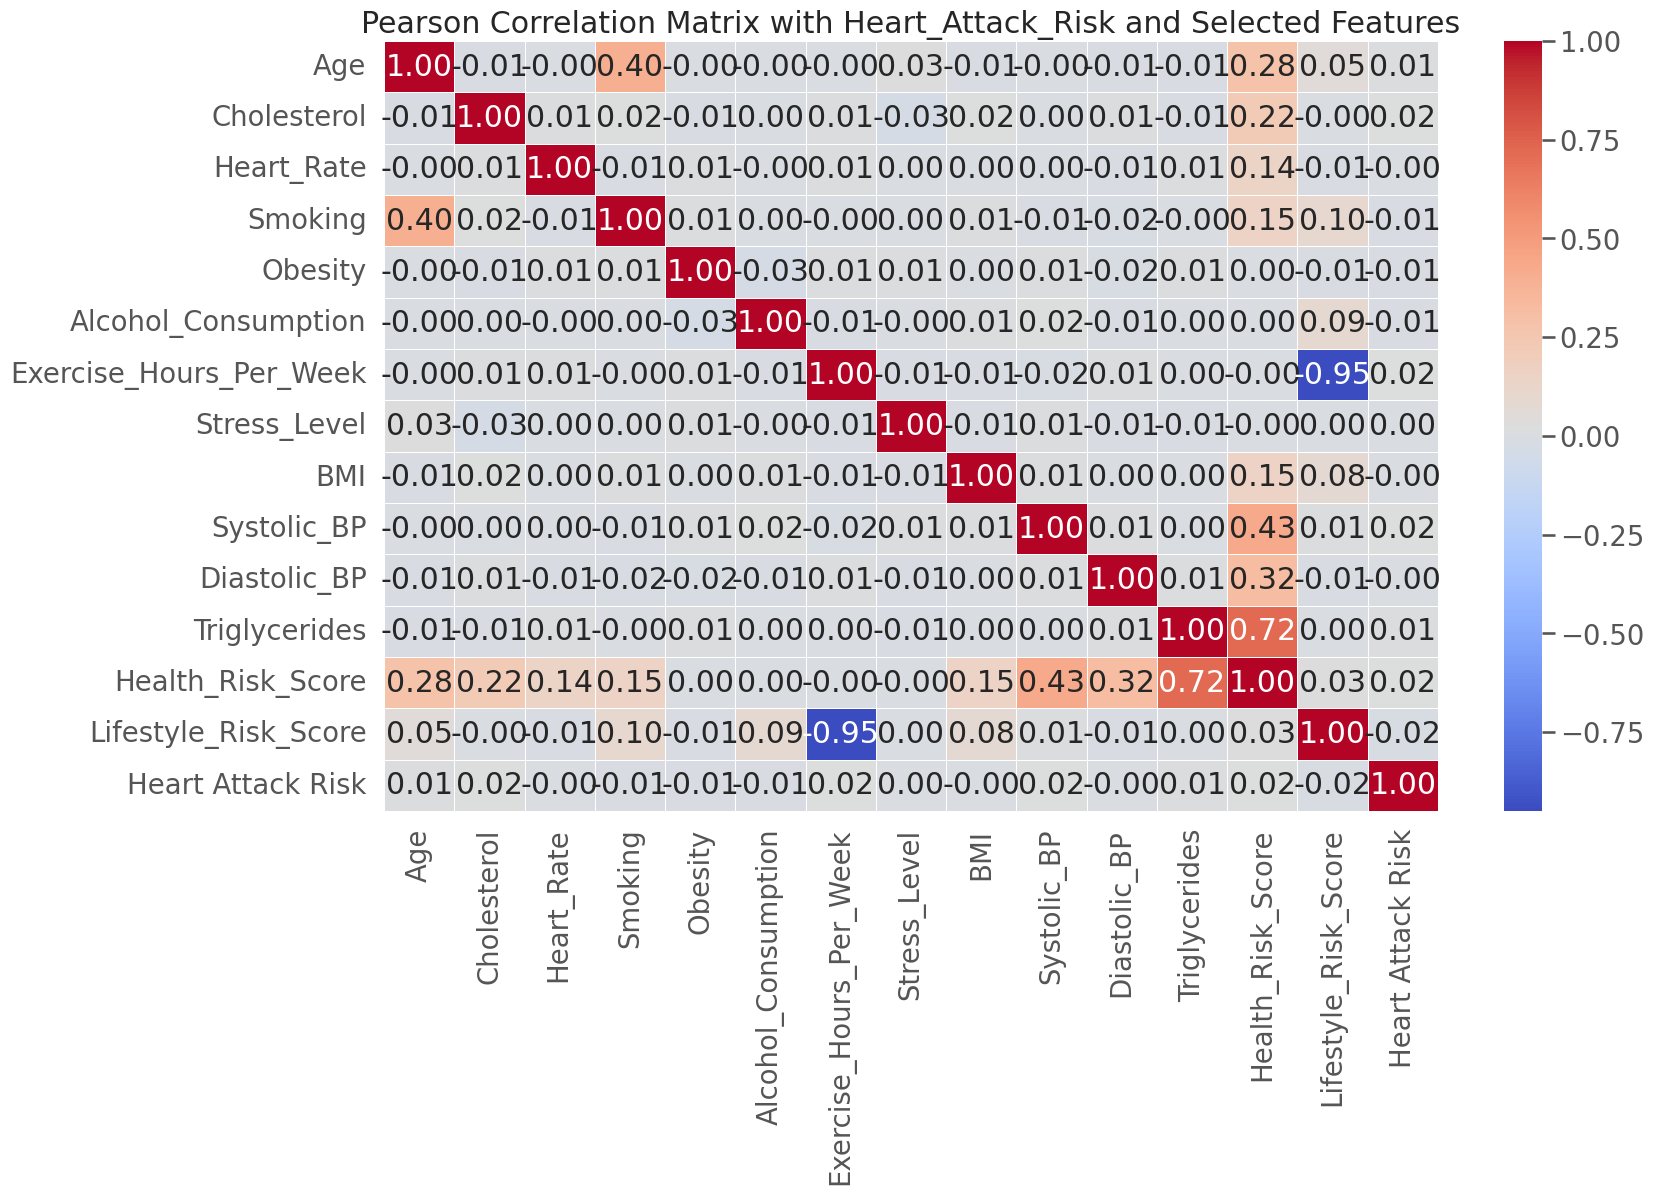

In [133]:
from scipy.stats import pearsonr

# Selecting relevant columns for the correlation matrix
selected_columns = [
    'Age', 'Cholesterol', 'Heart_Rate', 'Smoking', 'Obesity', 'Alcohol_Consumption',
    'Exercise_Hours_Per_Week', 'Stress_Level', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Triglycerides', 'Health_Risk_Score', 'Lifestyle_Risk_Score', 'Heart Attack Risk'
]

# Initialize an empty DataFrame to store correlation coefficients
correlation_matrix = pd.DataFrame(index=selected_columns, columns=selected_columns)

# Compute Pearson correlation for each pair of variables
for col1 in selected_columns:
    for col2 in selected_columns:
        corr, _ = pearsonr(train[col1], train[col2])
        correlation_matrix.loc[col1, col2] = round(corr, 2)

# Plotting the heatmap of the Pearson correlation matrix
plt.figure(figsize=(17, 10))
sns.heatmap(correlation_matrix.astype(float), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Matrix with Heart_Attack_Risk and Selected Features')
plt.show()


## <a id='toc1_4_'></a>[4️⃣ Reduce dataset dimensionality](#toc0_)


### <a id='toc1_4_1_'></a>[4.1. agglomerative hierarchical clustering](#toc0_)


In [134]:
ordinal_mappings = {
    'Physical_Mental_Health_Score_Category': {'Low': 1, 'Medium': 2, 'High': 3},
    'Risk_Category': {'Low': 1, 'Medium': 2, 'High': 3},
    'Age_Group': {'<30': 1, '30-45': 2, '45-60': 3, '60-75': 4, '75+': 5},
    'Lifestyle_Risk_Category':{'Low': 1,'High': 2}
}

for column, mapping in ordinal_mappings.items():
    train[column] = train[column].map(mapping).astype(int)


In [135]:
train[['Physical_Mental_Health_Score_Category', 'Risk_Category', 'Age_Group','Lifestyle_Risk_Category']].head()

,Physical_Mental_Health_Score_Category,Risk_Category,Age_Group,Lifestyle_Risk_Category
0,1,1,2,2
1,1,3,3,1
2,3,3,1,2
3,1,2,3,1
4,1,3,5,1


In [136]:
train.dtypes

,0
Patient_ID,object
Age,int64
Sex,int64
Cholesterol,int64
Heart_Rate,int64
Diabetes,int64
Family_History,int64
Smoking,int64
Obesity,int64
Alcohol_Consumption,int64


In [137]:
len(train.columns)

37

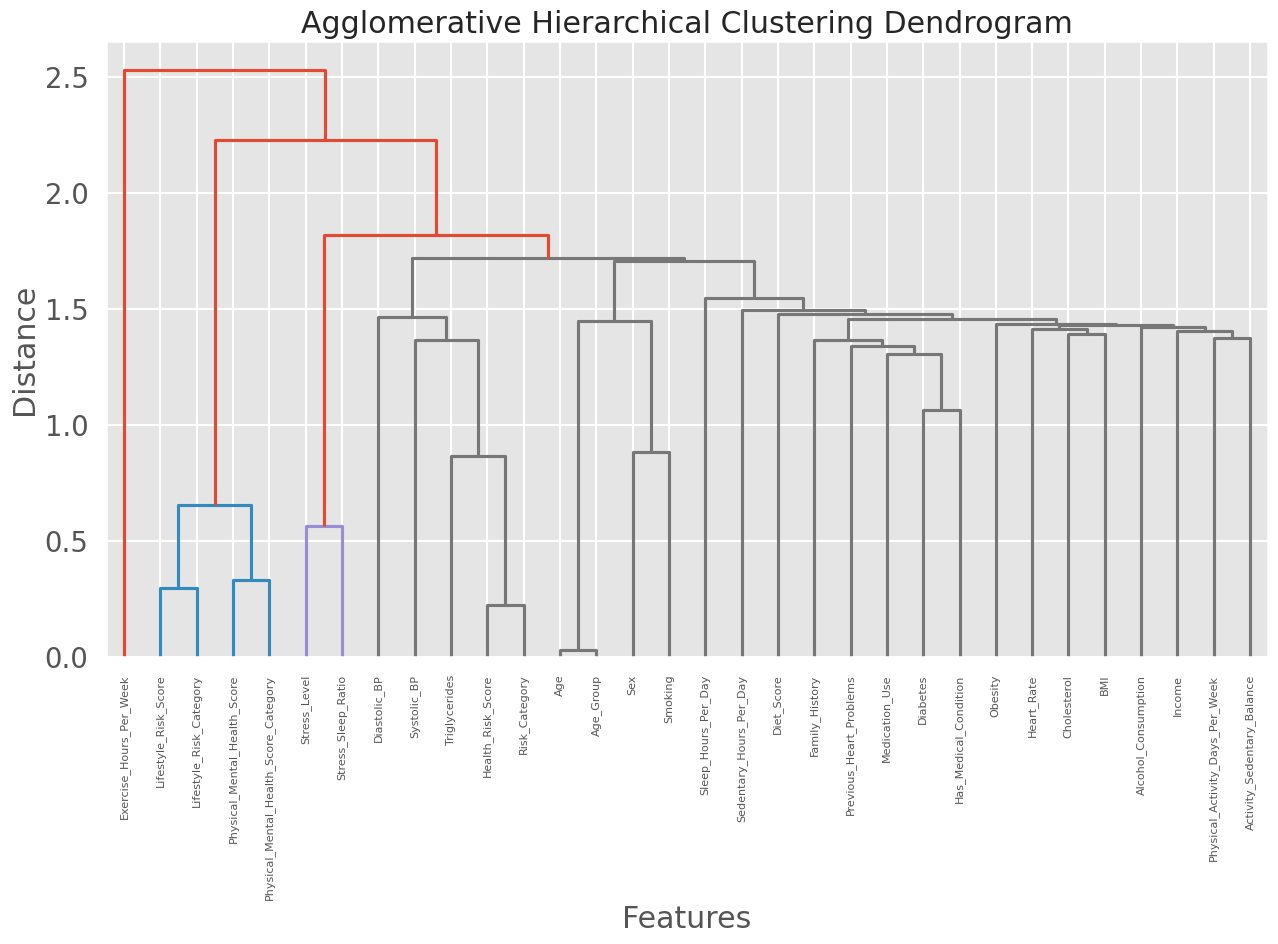

In [138]:

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler


y = train['Heart Attack Risk']  # Target variable
X = train.drop(columns=['Heart Attack Risk', 'Patient_ID', 'Country', 'Continent', 'Hemisphere'])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute the correlation matrix
correlation_matrix = np.corrcoef(X_scaled, rowvar=False)

# Perform hierarchical clustering using average linkage on the correlation matrix
linked = linkage(correlation_matrix, method='average')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked, labels=X.columns, leaf_rotation=90)
plt.title('Agglomerative Hierarchical Clustering Dendrogram')
plt.xlabel('Features')
plt.ylabel('Distance')
plt.show()

# Interpretation of the Dendrogram

## Overview
The dendrogram illustrates hierarchical clustering of features based on similarity. The **y-axis (Distance)** represents dissimilarity, while the **x-axis (Features)** shows the clustered variables.

## Key Insights
- **Closely Related Features (Low Distance)**:
  - "Exercise Hours Per Week," "Lifestyle Risk Score," and "Physical/Mental Health Score" cluster together.
  - "Stress Level" and "Stress-Sleep Ratio" form another group.
- **Moderately Related Features**:
  - "Diastolic BP" and "Systolic BP" cluster as expected.
  - "Triglycerides," "Health Risk Score," and "Risk Category" form another subgroup.
- **Distantly Related Features (High Distance)**:
  - "BMI," "Cholesterol," and "Heart Rate" cluster but with weakerlearning models.
ive").  

### **Feature Pairs Clustered at Very Low Distance**  
The following feature pairs are clustered at very low distances, indicating strong similarity or correlation:

- **"Exercise Hours Per Week"** & **"Lifestyle Risk Score"**  
- **"Lifestyle Risk Score"** & **"Physical/Mental Health Score"**  
- **"Stress Level"** & **"Stress-Sleep Ratio"**  
- **"Diastolic BP"** & **"Systolic BP"**  

These features are likely measuring closely related aspects of health and lifestyle, making them strong candidates for potential redundancy in analysis.
itions for merged pairs.  

### <a id='toc1_4_2_'></a>[4.2. PCA ](#toc0_)


**<span style= 'color:red'>Principal component analysis (PCA)</span>** is a statistical procedure that uses an <span style= 'color:red'>orthogonal transformation</span> to convert the variables of a dataset into a new set of variables which are linearly uncorrelated and called principal components. The <u>principal components</u> are ranked according to the variance of data along them. This technique can be used to <span style= 'color:green'>reduce the dimensionality of the dataset</span> by considering just the most important principal components.


In [139]:
train.columns


Index(['Patient_ID', 'Age', 'Sex', 'Cholesterol', 'Heart_Rate', 'Diabetes',
       'Family_History', 'Smoking', 'Obesity', 'Alcohol_Consumption',
       'Exercise_Hours_Per_Week', 'Previous_Heart_Problems', 'Medication_Use',
       'Stress_Level', 'Sedentary_Hours_Per_Day', 'Income', 'BMI',
       'Triglycerides', 'Physical_Activity_Days_Per_Week',
       'Sleep_Hours_Per_Day', 'Country', 'Continent', 'Hemisphere',
       'Systolic_BP', 'Diastolic_BP', 'Stress_Sleep_Ratio', 'Diet_Score',
       'Has_Medical_Condition', 'Physical_Mental_Health_Score',
       'Lifestyle_Risk_Score', 'Health_Risk_Score',
       'Physical_Mental_Health_Score_Category', 'Lifestyle_Risk_Category',
       'Age_Group', 'Risk_Category', 'Activity_Sedentary_Balance',
       'Heart Attack Risk'],
      dtype='object')

In [140]:
# Assuming df is your DataFrame with all the features
# First, select only numeric features (excluding IDs and categorical strings)
numeric_features = train.select_dtypes(include=['int64', 'float64', 'int32']).columns
numeric_df = train[numeric_features]

# Calculate correlation matrix
corr_matrix = numeric_df.corr()


# Extract highly correlated features (|r| ≥ 0.7)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) >= 0.7:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 2)
            ))

# Sort by absolute correlation value
high_corr_sorted = sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)

# Print results
print("\nHighly correlated feature pairs (|r| ≥ 0.7):")
for pair in high_corr_sorted:
    print(f"{pair[0]} & {pair[1]}: r = {pair[2]}")

# Get unique features involved in high correlations
all_high_corr_features = list(set([x for pair in high_corr for x in pair[:2]]))
print("\nFeatures involved in high correlations:", all_high_corr_features)


Highly correlated feature pairs (|r| ≥ 0.7):
Age_Group & Age: r = 0.98
Lifestyle_Risk_Score & Exercise_Hours_Per_Week: r = -0.95
Risk_Category & Health_Risk_Score: r = 0.87
Physical_Mental_Health_Score & Exercise_Hours_Per_Week: r = -0.85
Lifestyle_Risk_Category & Lifestyle_Risk_Score: r = 0.85
Lifestyle_Risk_Score & Physical_Mental_Health_Score: r = 0.84
Stress_Sleep_Ratio & Stress_Level: r = 0.83
Physical_Mental_Health_Score_Category & Physical_Mental_Health_Score: r = 0.83
Lifestyle_Risk_Category & Exercise_Hours_Per_Week: r = -0.83
Physical_Mental_Health_Score_Category & Exercise_Hours_Per_Week: r = -0.76
Physical_Mental_Health_Score_Category & Lifestyle_Risk_Score: r = 0.74
Lifestyle_Risk_Category & Physical_Mental_Health_Score: r = 0.73
Health_Risk_Score & Triglycerides: r = 0.72

Features involved in high correlations: ['Triglycerides', 'Age_Group', 'Stress_Sleep_Ratio', 'Lifestyle_Risk_Score', 'Age', 'Physical_Mental_Health_Score', 'Stress_Level', 'Health_Risk_Score', 'Lifesty

In [141]:
correlated_features = [
    ("Age_Group", "Age", 0.98),
    ("Lifestyle_Risk_Score", "Exercise_Hours_Per_Week", -0.95),
    ("Risk_Category", "Health_Risk_Score", 0.87),
    ("Physical_Mental_Health_Score", "Exercise_Hours_Per_Week", -0.85),
    ("Lifestyle_Risk_Category", "Lifestyle_Risk_Score", 0.85),
    ("Lifestyle_Risk_Score", "Physical_Mental_Health_Score", 0.84),
    ("Stress_Sleep_Ratio", "Stress_Level", 0.83),
    ("Physical_Mental_Health_Score_Category", "Physical_Mental_Health_Score", 0.83),
    ("Lifestyle_Risk_Category", "Exercise_Hours_Per_Week", -0.83),
    ("Physical_Mental_Health_Score_Category", "Exercise_Hours_Per_Week", -0.76),
    ("Physical_Mental_Health_Score_Category", "Lifestyle_Risk_Score", 0.74),
    ("Lifestyle_Risk_Category", "Physical_Mental_Health_Score", 0.73),
    ("Health_Risk_Score", "Triglycerides", 0.72)
]

In [142]:
duplicates_to_remove = [
    "Age", "Exercise_Hours_Per_Week", "Health_Risk_Score", "Lifestyle_Risk_Score",
    "Physical_Mental_Health_Score", "Stress_Level", "Triglycerides","Sleep_Hours_Per_Day","Sedentary_Hours_Per_Day","Physical_Activity_Days_Per_Week"
]

In [143]:
train_df = train.drop(columns=duplicates_to_remove, errors='ignore')

In [144]:
train_df.head()

,Patient_ID,Sex,Cholesterol,Heart_Rate,Diabetes,Family_History,Smoking,Obesity,Alcohol_Consumption,Previous_Heart_Problems,...,Diastolic_BP,Stress_Sleep_Ratio,Diet_Score,Has_Medical_Condition,Physical_Mental_Health_Score_Category,Lifestyle_Risk_Category,Age_Group,Risk_Category,Activity_Sedentary_Balance,Heart Attack Risk
0,RDG0550,1,200,48,0,1,1,1,1,0,...,90,0.285714,0,1,1,2,2,1,6.191285,1
1,NMA3851,0,262,46,1,0,1,0,0,1,...,105,1.000000,1,1,1,1,3,3,2.705978,1
2,TUI5807,0,140,54,0,1,0,0,1,1,...,109,0.300000,1,1,3,2,1,3,0.033045,0
3,YYT5016,0,163,53,0,1,1,1,1,0,...,62,0.777778,2,1,1,1,3,2,0.000000,1
4,ZAC5937,0,144,92,1,0,1,0,1,1,...,110,0.200000,2,1,1,1,5,3,0.213607,1


In [145]:
# Assuming df is your DataFrame with all the features
# First, select only numeric features (excluding IDs and categorical strings)
numeric_features = train_df.select_dtypes(include=['int64', 'float64', 'int32']).columns
numeric_df = train_df[numeric_features]

# Calculate correlation matrix
corr_matrix = numeric_df.corr()


# Extract highly correlated features (|r| ≥ 0.7)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) >= 0.7:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 2)
            ))

# Sort by absolute correlation value
high_corr_sorted = sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)

# Print results
print("\nHighly correlated feature pairs (|r| ≥ 0.7):")
for pair in high_corr_sorted:
    print(f"{pair[0]} & {pair[1]}: r = {pair[2]}")

# Get unique features involved in high correlations
all_high_corr_features = list(set([x for pair in high_corr for x in pair[:2]]))
print("\nFeatures involved in high correlations:", all_high_corr_features)


Highly correlated feature pairs (|r| ≥ 0.7):

Features involved in high correlations: []


In [146]:
len(train.columns)

37

In [147]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Remove non-numeric and identifier columns
non_pca_features = ['Patient_ID', 'Country', 'Continent', 'Hemisphere',"Heart Attack Risk"]
df_pca = train_df.drop(columns=non_pca_features)



# 3. Remove low-variance features (including binary categoricals with few 1s)
selector = VarianceThreshold(threshold=0.05)  # Keep features with >5% variance
df_pca = pd.DataFrame(selector.fit_transform(df_pca), columns=df_pca.columns[selector.get_support()])

# 4. Check for remaining high correlations
corr_matrix = df_pca.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper.columns if any(upper[column] > 0.85)]

if high_corr_features:
    print(f"Removing high-correlation features: {high_corr_features}")
    df_pca = df_pca.drop(columns=high_corr_features)

# 5. Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pca)

# 6. Perform PCA with optimal components
pca = PCA(n_components=0.95)  # Keep 95% variance
principal_components = pca.fit_transform(scaled_data)

# 7. Create comprehensive analysis
def analyze_pca_results(pca, feature_names):
    """Generate full PCA analysis report"""
    # Create loading matrix
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
        index=feature_names
    )

    # Explained variance
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Cumulative variance:", np.cumsum(pca.explained_variance_ratio_))



    return loadings

# Run analysis
loadings = analyze_pca_results(pca, df_pca.columns)

# 8. Create final PCA dataframe with interpretation
pca_df = pd.DataFrame(
    principal_components,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Add important metadata
pca_df['Heart_Attack_Risk'] = train['Heart Attack Risk'].values  # Assuming 'Heart Attack Risk' column exists

# Show feature contributions
print("\nDominant features per PC:")
for pc in loadings.columns:  # Just show first 5 PCs
    top_features = loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f"{pc}: {', '.join(top_features.index)}")

Explained variance ratio: [0.08633593 0.08171941 0.07038898 0.05142462 0.05077432 0.04940877
 0.04931046 0.049102   0.04807055 0.04774986 0.04735816 0.04717548
 0.04669063 0.04647101 0.04622731 0.04476471 0.04416279 0.04220463
 0.02015176]
Cumulative variance: [0.08633593 0.16805534 0.23844432 0.28986894 0.34064326 0.39005203
 0.43936249 0.48846449 0.53653504 0.5842849  0.63164306 0.67881854
 0.72550917 0.77198018 0.81820749 0.8629722  0.90713499 0.94933962
 0.96949138]

Dominant features per PC:
PC1: Smoking, Lifestyle_Risk_Category, Physical_Mental_Health_Score_Category
PC2: Physical_Mental_Health_Score_Category, Lifestyle_Risk_Category, Smoking
PC3: Risk_Category, Systolic_BP, Sex
PC4: Stress_Sleep_Ratio, Cholesterol, Age_Group
PC5: Activity_Sedentary_Balance, Family_History, Diastolic_BP
PC6: Diabetes, Medication_Use, Obesity
PC7: Previous_Heart_Problems, Alcohol_Consumption, Medication_Use
PC8: Alcohol_Consumption, BMI, Diabetes
PC9: Income, Diabetes, Diastolic_BP
PC10: Heart_Rate

In [148]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,Heart_Attack_Risk
0,-0.475541,0.775595,-1.702220,-1.004694,0.167888,-0.994804,-0.169546,-0.983136,-1.424500,-0.736926,0.082764,0.066735,2.007491,1.303435,-0.110948,-0.956085,0.913797,-0.333641,-1.005445,1
1,-0.352934,-1.442924,1.992461,-0.749047,1.130740,0.321058,0.471362,-0.496654,0.322132,-0.485135,-0.478706,0.344266,-2.001551,0.909435,1.369020,0.172830,-0.898067,-0.409749,-0.253600,1
2,-0.906968,2.375805,3.116382,-0.752247,1.847381,-2.189199,0.124050,-0.932010,-0.360219,-0.199211,-1.142460,-1.285424,0.105377,1.079416,-0.653406,-0.629584,0.429310,0.214818,1.105392,0
3,-1.804020,-0.589413,-0.704557,1.664662,-0.144365,-1.548380,0.371446,0.320993,-0.102788,-1.037166,0.519370,0.200625,1.384658,1.016983,0.888103,-0.952273,1.039134,1.025492,0.524238,1
4,-0.069584,-2.101037,2.038567,0.069240,0.989378,-0.413483,0.271657,1.408510,0.169312,1.436232,-0.520709,-1.284451,-2.030947,0.969387,1.088694,-1.469109,0.634709,0.257002,-0.543424,1


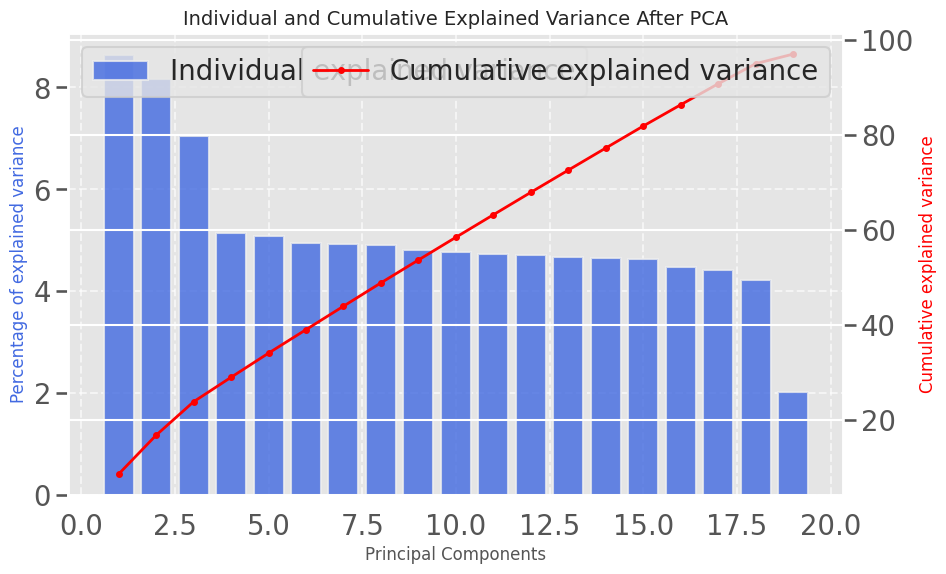

In [149]:
# Extract explained variance ratio from PCA
explained_variance_ratio = pca.explained_variance_ratio_  # After applying PCA in your project
cumulative_variance = np.cumsum(explained_variance_ratio)

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for individual explained variance
ax1.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio * 100,
        color='royalblue', alpha=0.8, label='Individual explained variance')

# Line plot for cumulative explained variance
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100,
         color='red', marker='o', linestyle='-', linewidth=2, markersize=4,
         label='Cumulative explained variance')

# Labels and Titles
ax1.set_xlabel("Principal Components", fontsize=12)
ax1.set_ylabel("Percentage of explained variance", fontsize=12, color='royalblue')
ax2.set_ylabel("Cumulative explained variance", fontsize=12, color='red')
plt.title("Individual and Cumulative Explained Variance After PCA", fontsize=14)

# Legend
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Grid and style
ax1.grid(True, linestyle="--", alpha=0.6)
plt.show()


## <a id='toc1_5_'></a>[5️⃣ Evaluating Preprocessed Datasets for Classification](#toc0_)


### <a id='toc1_5_1_'></a>[5.1. Overview of the approach](#toc0_)


After applying **feature engineering**, **dimensionality reduction (PCA)**, and **data preprocessing**, we now evaluate the impact of these transformations on classification performance. The goal is to determine how well the preprocessed dataset supports accurate **Heart Attack Risk Prediction** using machine learning models.  

### 🔍 Key Steps in This Evaluation:  
1. **Baseline Model Performance** – Train classifiers on the original dataset to establish a benchmark.  
2. **Comparison with Preprocessed Data** – Assess how preprocessing (feature selection, PCA, scaling) impacts model accuracy.  
3. **Model Selection** – Evaluate different classification algorithms (e.g., Logistic Regression, Random Forest, XGBoost).  
4. **Performance Metrics** – Use **accuracy, precision, recall, F1-score, and AUC-ROC** to measure effectiveness.  
5. **Cross-validation & Hyperparameter Tuning** – Ensure model robustness and optimize parameters for better generalization.  

This section provides a structured approach to **validating data preprocessing choices** and ensuring they enhance classification outcomes. 🚀

##  Evaluating Classifiers on Different Datasets  

To assess the impact of preprocessing, we train and evaluate classifiers on multiple versions of the dataset:  
- **Raw dataset** (without preprocessing)  
- **Feature-selected dataset** (after removing low-variance & highly correlated features)  
- **PCA-transformed dataset** (dimensionality reduction applied)  

This comparison helps determine which preprocessing steps improve model performance.  

-

## 5.3 Defining Performance Metrics  

To measure classifier effectiveness, we use key evaluation metrics:  
- **Accuracy** – Measures overall correctness of predictions.  
- **Precision & Recall** – Evaluate model performance in detecting high-risk patients.  
- **F1-Score** – Balances precision and recall for better assessment.  
- **AUC-ROC** – Measures how well the model distinguishes between risk classes.  

These metrics provide a **comprehensive view** of model performance beyond just acacy.  

---

## 5.4 Hyperparameter Tuning for Optimal Classifiers  

To improve classification performance, we fine-tune hyperparameters using techniques like:  
- **Grid Search** – Exhaustively tests predefined parameter combinations.  
- **Random Search** – Randomly samples hyperparameter values for efficiency.  
- **Bayesian Optimization** – Uses probabilistic models to find optimal settings.  

This step ensures that each classifier operates at its **best possiblnfiguration**.  

---

## 5.5 🔄 Cross-Validation for Reliable Performance Estimation  

To avoid overfitting and ensure **generalization**, we apply **K-Fold Cross-Validation**:  
- The dataset is split into **K subsets**, where each subset serves as a validation set once.  
- The model is trained **K times**, ensuring performance consistency.  
- **Stratified K-Fold** is used to maintain class balance in each fold.  

This provides a **robust performance estimate**, preventing biased results from a single train-test split. ✅  
en computational efficiency and accuracy. 🔍📈  


### <a id='toc1_5_2_'></a>[5.2. Implementing Grid Search for Model Optimization](#toc0_)


In [150]:


def do_gridsearch_with_cv(model, param_grid, X_train, y_train, cv=5, scoring='accuracy', verbose=1):
    """
    Performs Grid Search with Cross-Validation to find the best hyperparameters.

    Parameters:
    - model: The machine learning model to optimize.
    - param_grid: Dictionary containing hyperparameters to search.
    - X_train, y_train: Training data and labels.
    - cv: Number of cross-validation folds (default: 5).
    - scoring: Metric used for optimization (default: 'accuracy').
    - verbose: Level of verbosity for GridSearchCV (default: 1).

    Returns:
    - Best estimator from grid search.
    """
    grid_search = GridSearchCV(model, param_grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=verbose)
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_, grid_search

In [151]:
def score_on_test_set(model, X_test, y_test):
    """
    Evaluates the model on the test set using multiple performance metrics.

    Parameters:
    - model: Trained model.
    - X_test, y_test: Test data and labels.

    Returns:
    - Dictionary with accuracy, precision, recall, F1-score, and AUC-ROC.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    scores = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='binary'),
        "Recall": recall_score(y_test, y_pred, average='binary'),
        "F1-Score": f1_score(y_test, y_pred, average='binary'),
        "AUC-ROC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

    return scores

In [152]:
def print_best_grid_search_scores_with_params(grid_search):
    """
    Prints the best scores and hyperparameters from the Grid Search.

    Parameters:
    - grid_search: Fitted GridSearchCV object.
    """
    print("\nBest Grid Search Score: {:.4f}".format(grid_search.best_score_))
    print("Best Hyperparameters:", grid_search.best_params_)

### <a id='toc1_5_3_'></a>[5.3 Comparison of Different Preprocessing Strategies](#toc0_)


In [153]:
train_df.columns

Index(['Patient_ID', 'Sex', 'Cholesterol', 'Heart_Rate', 'Diabetes',
       'Family_History', 'Smoking', 'Obesity', 'Alcohol_Consumption',
       'Previous_Heart_Problems', 'Medication_Use', 'Income', 'BMI', 'Country',
       'Continent', 'Hemisphere', 'Systolic_BP', 'Diastolic_BP',
       'Stress_Sleep_Ratio', 'Diet_Score', 'Has_Medical_Condition',
       'Physical_Mental_Health_Score_Category', 'Lifestyle_Risk_Category',
       'Age_Group', 'Risk_Category', 'Activity_Sedentary_Balance',
       'Heart Attack Risk'],
      dtype='object')

In [154]:
pca_df.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'Heart_Attack_Risk'],
      dtype='object')

In [155]:
import random

# Define a random seed for reproducibility
SEED = 42

# Set the seed for various libraries
np.random.seed(SEED)
random.seed(SEED)

# Extract the target variable "heart attack risk"
df_y = train_df["Heart Attack Risk"]

# Remove the target from the feature set
df_X = train_df.drop(columns=["Heart Attack Risk","Hemisphere","Continent","Country","Patient_ID"])

pca_X=pca_df.drop(columns=["Heart_Attack_Risk"])

In [156]:
# The whole dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=SEED)

# The dataset reduced by PCA (80% training, 20% testing)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(pca_X, df_y, test_size=0.2, random_state=SEED)

In [157]:
# Let's check the shapes :
print("Shape of the full train dataset:", X_train.shape)
print("Shape of the transformed train dataset using the first 10 Principal Components", X_train_pca.shape)

Shape of the full train dataset: (5608, 22)
Shape of the transformed train dataset using the first 10 Principal Components (5608, 19)


# 📌 SMOTE (Synthetic Minority Over-sampling Technique)

## 🔹 What is SMOTE?
**SMOTE** is an oversampling technique used to **balance imbalanced datasets** by **generating synthetic samples** for the minority class instead of duplicating existing ones.

---

## 🔹 Why Use SMOTE?
- ✅ **Handles class imbalance** → Prevents the model from being biased toward the majority class.
- ✅ **Avoids overfitting** → Unlike random oversampling (which duplicates samples), SMOTE generates **new synthetic examples**.
- ✅ **Improves model performance** → Leads to better generalization, especially for classifiers sensitive to class imbalance (e.g., Decision Trees, Random Forest, etc.).

---

## 🔹 How SMOTE Works
1. Selects a random **minority class instance**.
2. Finds its **k nearest neighbors** (default `k=5`).
3. Randomly selects one of these neighbors.
4. Creates a **new synthetic instance** somewhere along the line joining the two points.

🔹 **Example Visualization:**  
🟢 (Minority Class)  
🔵 (Majority Class)  
SMOTE generates new 🟢 points **between existing minority class points**.

---

## 🔹 Implementing SMOTE in Python
You can apply SMOTE using the `imbalanced-learn` (`imblearn`) library:




In [158]:
df_X.dtypes

,0
Sex,int64
Cholesterol,int64
Heart_Rate,int64
Diabetes,int64
Family_History,int64
Smoking,int64
Obesity,int64
Alcohol_Consumption,int64
Previous_Heart_Problems,int64
Medication_Use,int64


In [159]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Apply SMOTE to the PCA-reduced training set
X_train_pca_resampled, y_train_pca_resampled = smote.fit_resample(X_train_pca, y_train_pca)

# Print class distribution before & after
print("Original class distribution:", Counter(y_train))
print("After SMOTE class distribution:", Counter(y_train_resampled))

# Print PCA-resampled class distribution
print("Original PCA class distribution:", Counter(y_train_pca))
print("After PCA SMOTE class distribution:", Counter(y_train_pca_resampled))


Original class distribution: Counter({0: 3605, 1: 2003})
After SMOTE class distribution: Counter({0: 3605, 1: 3605})
Original PCA class distribution: Counter({0: 3605, 1: 2003})
After PCA SMOTE class distribution: Counter({0: 3605, 1: 3605})


In [160]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier, StackingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
# Set seed for reproducibility
SEED = 42

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, random_state=SEED, shuffle=True)

# Dictionary of all supervised classification models
models = {
    # Linear Models
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Ridge Classifier": RidgeClassifier(random_state=SEED),
    "SGD Classifier": SGDClassifier(random_state=SEED),

    # Tree-Based Models
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED),
    "Random Forest (Balanced)": RandomForestClassifier(random_state=SEED, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "Extra Trees": ExtraTreesClassifier(random_state=SEED),

    # Support Vector Machine
    "Support Vector Machine (RBF)": SVC(kernel="rbf", random_state=SEED),

    # Nearest Neighbors
    "K-Nearest Neighbors": KNeighborsClassifier(),

    # Discriminant Analysis
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),

    # Neural Network
    "Neural Network (MLP)": MLPClassifier(random_state=SEED),

    # Probabilistic Models
    "Gaussian Naive Bayes": GaussianNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),

    # Advanced Tree-Based & Boosting Models
    "XGBoost": XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=SEED),

    # Ensemble Methods
    "Voting Classifier": VotingClassifier(estimators=[
        ("Random Forest", RandomForestClassifier(random_state=SEED)),
        ("Gradient Boosting", GradientBoostingClassifier(random_state=SEED)),
        ("XGBoost", XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'))
    ], voting='soft'),

    "Stacking Classifier": StackingClassifier(estimators=[
        ("Random Forest", RandomForestClassifier(random_state=SEED)),
        ("Gradient Boosting", GradientBoostingClassifier(random_state=SEED)),
        ("XGBoost", XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'))
    ], final_estimator=LogisticRegression()),

    "Bagging Classifier": BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=SEED)
}

# Print initialized models
for name, model in models.items():
    print(f"{name}: {model}")

Logistic Regression: LogisticRegression(random_state=42)
Ridge Classifier: RidgeClassifier(random_state=42)
SGD Classifier: SGDClassifier(random_state=42)
Decision Tree: DecisionTreeClassifier(random_state=42)
Random Forest: RandomForestClassifier(random_state=42)
Random Forest (Balanced): RandomForestClassifier(class_weight='balanced', random_state=42)
Gradient Boosting: GradientBoostingClassifier(random_state=42)
Extra Trees: ExtraTreesClassifier(random_state=42)
Support Vector Machine (RBF): SVC(random_state=42)
K-Nearest Neighbors: KNeighborsClassifier()
Linear Discriminant Analysis: LinearDiscriminantAnalysis()
Quadratic Discriminant Analysis: QuadraticDiscriminantAnalysis()
Neural Network (MLP): MLPClassifier(random_state=42)
Gaussian Naive Bayes: GaussianNB()
Bernoulli Naive Bayes: BernoulliNB()
XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early

In [161]:
def train_and_evaluate_models(models, param_grids, X, y, kf, cv=5, scoring='accuracy'):
    """
    Performs Grid Search for each model, trains using Stratified K-Fold, and evaluates performance.

    Parameters:
    - models: Dictionary of model names and instantiated classifiers.
    - param_grids: Dictionary of model names and their corresponding hyperparameter grids.
    - X, y: Features and labels.
    - kf: Stratified K-Fold cross-validator.
    - cv: Number of cross-validation folds for Grid Search (default: 5).
    - scoring: Metric used for optimization in Grid Search (default: 'accuracy').

    Returns:
    - Dictionary containing performance metrics for each model.
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔍 Performing Grid Search for {name}...")

        # Perform Grid Search to find the best hyperparameters
        best_model, grid_search = do_gridsearch_with_cv(model, param_grids[name], X, y, cv=cv, scoring=scoring, verbose=0)

        print(f"✅ Best parameters for {name}: {grid_search.best_params_}")

        scores_list = []  # Store scores across folds

        for train_idx, test_idx in kf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Train the best model from Grid Search on each fold
            best_model.fit(X_train, y_train)
            scores = score_on_test_set(best_model, X_test, y_test)
            scores_list.append(scores)

        # Compute the average scores across all folds
        averaged_scores = {
            metric: np.mean([fold[metric] for fold in scores_list if fold[metric] is not None])
            for metric in scores_list[0]
        }

        results[name] = {
            "Best Params": grid_search.best_params_,
            "Scores": averaged_scores
        }

    return results


In [162]:
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [163]:
param_grids = {
    'Gaussian Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],  # Regularization strength
        "solver": ["liblinear", "lbfgs"]
    },

    "Ridge Classifier": {
        "alpha": [0.1, 1, 10, 100]  # Regularization strength
    },

    "SGD Classifier": {
        "loss": ["hinge", "log_loss"],  # SVM (hinge) or Logistic Regression (log_loss)
        "penalty": ["l2", "l1", "elasticnet"],
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1],  # Regularization strength
        "max_iter": [1000, 5000]
    },

    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest (Balanced)": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 6, 10],
        "subsample": [0.8, 1.0]
    },

    "Support Vector Machine (RBF)": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    },

    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7, 9],  # Number of neighbors
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },

    "Linear Discriminant Analysis": {
        "solver": ["svd", "lsqr", "eigen"]
    },

    "Quadratic Discriminant Analysis": {
        "reg_param": [0.0, 0.1, 0.5, 1.0]  # Regularization parameter
    },

    "Neural Network (MLP)": {
        "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 100)],  # Network architecture
        "activation": ["relu", "tanh", "logistic"],
        "solver": ["adam", "sgd"],
        "alpha": [0.0001, 0.001, 0.01]  # L2 regularization
    },

    # Add grid search for additional models
    "Extra Trees": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 6, 10],
        "subsample": [0.8, 1.0]
    },

    "LightGBM": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 6, 10],
        "subsample": [0.8, 1.0]
    },

    "Voting Classifier": {
        "voting": ["hard", "soft"]
    },

    "Stacking Classifier": {
        "final_estimator": [LogisticRegression(), RidgeClassifier(), DecisionTreeClassifier()],
        "cv": [3, 5]
    },

    "Bagging Classifier": {
        "n_estimators": [10, 50, 100],
        "max_samples": [0.5, 0.8, 1.0],
        "max_features": [0.5, 0.8, 1.0]
    },
    'Bernoulli Naive Bayes': {
        'alpha': [0.1, 0.5, 1.0],
        'binarize': [0.0, 0.5, 1.0]
    },
}


In [164]:
results = train_and_evaluate_models(models,param_grids, X_train_pca_resampled, y_train_pca_resampled, kf)


🔍 Performing Grid Search for Logistic Regression...
✅ Best parameters for Logistic Regression: {'C': 0.01, 'solver': 'liblinear'}

🔍 Performing Grid Search for Ridge Classifier...
✅ Best parameters for Ridge Classifier: {'alpha': 0.1}

🔍 Performing Grid Search for SGD Classifier...
✅ Best parameters for SGD Classifier: {'alpha': 0.001, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l1'}

🔍 Performing Grid Search for Decision Tree...
✅ Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

🔍 Performing Grid Search for Random Forest...
✅ Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

🔍 Performing Grid Search for Random Forest (Balanced)...
✅ Best parameters for Random Forest (Balanced): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

🔍 Performing Grid Search for Gradient Boosting...
✅ Best parameters fo

In [167]:
# Print results in a readable format
for model_name, result in results.items():
    print(f"\n📊 Results for {model_name}:")
    print(f"   🔹 Best Parameters: {result['Best Params']}")
    print("   🔹 Scores:")
    for metric, score in result["Scores"].items():
        print(f"      - {metric}: {score:.4f}")



📊 Results for Logistic Regression:
   🔹 Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
   🔹 Scores:
      - Accuracy: 0.5042
      - Precision: 0.5041
      - Recall: 0.5146
      - F1-Score: 0.5092
      - AUC-ROC: 0.5040

📊 Results for Ridge Classifier:
   🔹 Best Parameters: {'alpha': 0.1}
   🔹 Scores:
      - Accuracy: 0.5047
      - Precision: 0.5046
      - Recall: 0.5146
      - F1-Score: 0.5095
      - AUC-ROC: nan

📊 Results for SGD Classifier:
   🔹 Best Parameters: {'alpha': 0.001, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l1'}
   🔹 Scores:
      - Accuracy: 0.4882
      - Precision: 0.4808
      - Recall: 0.3648
      - F1-Score: 0.4083
      - AUC-ROC: nan

📊 Results for Decision Tree:
   🔹 Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
   🔹 Scores:
      - Accuracy: 0.5931
      - Precision: 0.5868
      - Recall: 0.6275
      - F1-Score: 0.6063
      - AUC-ROC: 0.5931

📊 Results for Random Forest:
   🔹 Be

In [166]:
print(results)

{'Logistic Regression': {'Best Params': {'C': 0.01, 'solver': 'liblinear'}, 'Scores': {'Accuracy': np.float64(0.5041608876560333), 'Precision': np.float64(0.5040704836203527), 'Recall': np.float64(0.5145631067961165), 'F1-Score': np.float64(0.5092185214511576), 'AUC-ROC': np.float64(0.5040114188761563)}}, 'Ridge Classifier': {'Best Params': {'alpha': 0.1}, 'Scores': {'Accuracy': np.float64(0.5047156726768378), 'Precision': np.float64(0.5046297507147044), 'Recall': np.float64(0.5145631067961165), 'F1-Score': np.float64(0.5095009932607328), 'AUC-ROC': np.float64(nan)}}, 'SGD Classifier': {'Best Params': {'alpha': 0.001, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l1'}, 'Scores': {'Accuracy': np.float64(0.48821081830790564), 'Precision': np.float64(0.4807954631406746), 'Recall': np.float64(0.3647711511789181), 'F1-Score': np.float64(0.4083139713069667), 'AUC-ROC': np.float64(nan)}}, 'Decision Tree': {'Best Params': {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_sa